# Returning booster, part 6: GNC validation, analysis, and the autodiff advantage

Parts 1–5 of this series built up a high-fidelity, closed-loop, multi-phase, sensor-feedback simulation of a propulsively-landed booster. Each part landed a useful artifact — a 6-DOF plant, an NMPC controller, a multi-phase dispatcher, an aero/grid-fin upgrade, an EKF. But a GNC engineer reading Parts 1–5 would still ask the question that ends every design review: *how do we know this works?* This notebook is the answer.

Specifically, we close six gaps that production GNC validation requires and that the tutorial series has not yet addressed:

1. **Linearized closed-loop analysis.** Eigenvalues, Bode, Nyquist, gain and phase margins of the booster under a stabilizing controller, with each mode physically named.
2. **Monte Carlo dispersion.** A 1 000-trial vectorized sweep over initial condition, wind seed, and mass error, yielding landing-footprint statistics and a success-rate number.
3. **The autodiff advantage.** A head-to-head wall-clock comparison of `jax.grad` versus finite differences for closed-loop gain tuning, with a clear-eyed survey of why the rest of the industry does not have this option today.
4. **Real-time and embedded realities.** A short, concrete discussion of what *production* flight software must do that we do not — RTOS, fixed-point, watchdogs.
5. **Robust control synthesis.** An LQG controller designed at the linearized hover operating point, with closed-loop eigenvalues and margins.
6. **Convex trajectory optimization.** A brief tour of lossless convexification — what every production rocket-landing system actually uses — together with the formal-verification and ITAR landscape.

**Reading time:** ≈45 minutes. **Runtime on CPU:** ≈3–6 minutes (1 000-trial Monte Carlo dominates).

> **Position in the series.** Parts 1–5 *build*. Part 6 *validates*. Nothing new is added to the plant; we instead step back and ask the questions that a Critical Design Review would ask. We linearize a Part-1-class plant under a stabilizing PD controller (a deliberate simplification of Part 2's NMPC — see §1) and use that linear model for all frequency-domain analysis. The full nonlinear plant is used everywhere else.


## Prerequisites

- **Parts 1–2** for the plant and the closed-loop NMPC architecture. We reuse Part 1's 13-state dynamics verbatim.
- **Part 5** for the noise / sensor / EKF picture is *not* required here; the Monte Carlo uses truth-state feedback because the headline statistic we want is "given perfect estimation, what is the GNC system's robustness to dispersion?". Stacking estimation noise on top of dispersion is left as an exercise.
- Comfort with classical control (Bode, Nyquist, margins) at the level of an undergraduate controls course.
- `python-control` is required for §1 and §5. `cvxpy` and `slycot` are *optional* (we discuss what we'd do if they were installed; the notebook runs either way).

> **Note: the linearization choice.** We linearize the closed-loop *PD-controlled* plant rather than the *NMPC-controlled* plant. This is deliberate: NMPC's policy is implicitly defined by the solution of a nonlinear program at each step, and `jaxonomy.linearize` would either need to differentiate through the NLP (slow, sometimes ill-defined) or treat the controller as a black box. A PD controller has the same closed-loop *eigenvalues you would design for* near a hover trim — it is the natural object for stability analysis. Production teams do exactly this: gain-scheduled LQR/PD for linear analysis, NMPC for trajectory tracking, and a separate stability proof connecting the two via small-gain or assume/guarantee contracts.


## Setup: re-import the Part 1 plant

We re-define the Part-1 plant (13 states, 3 controls, no aero) inline so this notebook is self-contained. Bit-for-bit identical numbers to Part 1: $T_\text{max}=600$ kN, $I_\text{sp}=280$ s, dry mass $25\,000$ kg, fuel $5\,000$ kg, gimbal $\pm 10^\circ$, throttle $[0.4, 1.0]$, Z-Y-X Euler attitude. The pure-function ODE right-hand side `booster_ode_rhs` is what every later block calls.


In [1]:
# Standard scientific Python
import time as time_mod
import warnings
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# JAX with float64 — Riccati solves and Jacobians need the precision
from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

# python-control: required for §1 (margins, Nyquist) and §5 (LQG)
import control as ct

# Jaxonomy
import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    Constant,
    SourceBlock,
    FeedthroughBlock,
    LinearQuadraticRegulator,
)
from jaxonomy.library.lqg import LinearQuadraticGaussian
from jaxonomy.library.linear_system import linearize, LinearizedSystem, LTISystem
from jaxonomy.diagnostics import (
    analyze_saturation,
    analyze_phase_activity,
    analyze_control_oscillation,
)
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

# Reproducibility — every random draw in this notebook seeds from RNG_SEED.
RNG_SEED = 11
np.random.seed(RNG_SEED)


In [2]:
# ----- Part 1 booster: physical parameters (identical to Part 1) ----------
M_DRY    = 25_000.0
M_FUEL_0 = 5_000.0
T_MAX    = 600_000.0
ETA_MIN  = 0.4
ETA_MAX  = 1.0
ISP      = 280.0
G0       = 9.80665
G        = 9.81
DELTA_MAX = np.deg2rad(10.0)
L_BOOSTER = 40.0
R_BOOSTER = 1.85

def cylinder_inertia(m, L, r):
    Ixx = Iyy = m * (3 * r**2 + L**2) / 12.0
    Izz = 0.5 * m * r**2
    return Ixx, Iyy, Izz

IXX0, IYY0, IZZ0 = cylinder_inertia(M_DRY + M_FUEL_0, L_BOOSTER, R_BOOSTER)
ETA_HOVER = (M_DRY + M_FUEL_0) * G / T_MAX  # hover throttle at full fuel
print(f"Hover throttle: {ETA_HOVER:.3f}   (must be in [{ETA_MIN}, {ETA_MAX}])")


Hover throttle: 0.490   (must be in [0.4, 1.0])


In [3]:
def euler_zyx_rotation(phi, theta, psi):
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    return jnp.array([
        [cpsi * cth, cpsi * sth * sphi - spsi * cphi, cpsi * sth * cphi + spsi * sphi],
        [spsi * cth, spsi * sth * sphi + cpsi * cphi, spsi * sth * cphi - cpsi * sphi],
        [-sth,       cth * sphi,                       cth * cphi                     ],
    ])

def euler_zyx_kinematics_inv(phi, theta):
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth, sth = jnp.cos(theta), jnp.sin(theta)
    tth = sth / cth
    return jnp.array([
        [1.0, sphi * tth,   cphi * tth],
        [0.0, cphi,        -sphi      ],
        [0.0, sphi / cth,   cphi / cth],
    ])


def booster_ode_rhs(state, control, time, F_wind_W,
                    m_dry=M_DRY, T_max=T_MAX, isp=ISP, g0=G0, g=G,
                    L=L_BOOSTER, Ixx=IXX0, Iyy=IYY0, Izz=IZZ0):
    '''Full 13-state booster ODE RHS. Identical to Parts 1-2.'''
    pos   = state[0:3]
    vel   = state[3:6]
    eta_a = state[6:9]
    omega = state[9:12]
    m_f   = state[12]

    eta_throttle, delta_y, delta_z = control
    phi, theta, psi = eta_a
    m_total = m_dry + jnp.maximum(m_f, 0.0)

    F_B = eta_throttle * T_max * jnp.array([
        jnp.sin(delta_y),
       -jnp.sin(delta_z),
        jnp.cos(delta_y) * jnp.cos(delta_z),
    ])
    R_wb = euler_zyx_rotation(phi, theta, psi)
    F_W  = R_wb @ F_B
    G_W  = jnp.array([0.0, 0.0, -m_total * g])
    acc  = (F_W + G_W + F_wind_W) / m_total

    tau_B = jnp.array([
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_z),
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_y),
         0.0,
    ])
    I_diag = jnp.array([Ixx, Iyy, Izz])
    Iomega = I_diag * omega
    omega_dot = (tau_B - jnp.cross(omega, Iomega)) / I_diag

    W_inv = euler_zyx_kinematics_inv(phi, theta)
    eta_dot = W_inv @ omega

    m_f_dot = jnp.where(m_f > 0.0, -eta_throttle * T_max / (isp * g0), 0.0)
    return jnp.concatenate([vel, acc, eta_dot, omega_dot, jnp.array([m_f_dot])])


In [4]:
class BoosterWithWind(LeafSystem):
    '''Truth plant: Part-1 booster with an additional wind-force input port.

    Two input ports:
        (0) u = [eta, delta_y, delta_z]
        (1) F_wind_W = world-frame wind force [N]
    One output port:
        (0) x = full 13-state vector
    '''
    def __init__(self, x0=None, m_dry_override=None, name="booster"):
        super().__init__(name=name)
        self.declare_dynamic_parameter("m_dry",
            m_dry_override if m_dry_override is not None else M_DRY)
        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_input_port(name="F_wind_W")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **params):
        x = state.continuous_state
        u, F_wind_W = inputs
        return booster_ode_rhs(
            x, u, time, F_wind_W, m_dry=params["m_dry"],
        )


## 1. Linearized closed-loop analysis at hover

The first thing a GNC engineer does with a new plant + controller pair is to *linearize the closed loop* at a representative operating point and read off the eigenvalues, the Bode magnitude/phase, and the Nyquist locus. These three plots answer the three questions every reviewer asks:

1. **Is the closed loop stable?** (eigenvalues' real parts negative?)
2. **How much disturbance attenuation does it provide and at what frequencies?** (Bode magnitude)
3. **How close are we to instability?** (gain margin, phase margin from the Nyquist plot)

For us, "the controller" here is a **stabilizing PD controller about hover**, not the NMPC of Part 2. We make this swap on purpose: NMPC's policy is the solution of an NLP and is not naturally Jacobian-differentiable, while a PD controller gives us a clean linear closed loop whose eigenvalues are exactly the eigenvalues you would design for. Production GNC teams do the same thing — they ship NMPC for trajectory tracking but analyze stability with a linear controller of equivalent gain.

### 1.1 Hover trim and the PD controller

At hover, the booster is upright, stationary, with throttle balancing gravity exactly:
$$
\eta^* = \frac{m\,g}{T_\text{max}}, \qquad \delta_y^* = \delta_z^* = 0, \qquad \boldsymbol{\xi}^* = \mathbf{0}, \qquad \boldsymbol{\dot\xi}^* = \mathbf{0}, \qquad \boldsymbol{\eta}_\text{att}^* = \mathbf{0}.
$$

A textbook attitude PD controller uses **pitch** ($\theta$) to drive lateral $x$-position to zero, and **roll** ($\phi$) to drive lateral $y$-position to zero. Yaw ($\psi$) is uncontrolled in this single-engine model (see Part 1 §4: only $\delta_y, \delta_z$ produce torques about body-y and body-x, never about body-z). The signs of every gain are picked by inspecting the linearization of the open-loop plant directly:

- $A_p[v_x, \theta] = +g$: positive pitch tilts the thrust vector to give $+x$ acceleration. So $x>0 \Rightarrow \theta^\text{cmd}<0$.
- $A_p[v_y, \phi] = -g$: positive roll tilts the thrust vector to give $-y$ acceleration. So $y>0 \Rightarrow \phi^\text{cmd}>0$.
- $B_p[v_z, \eta] = +T_\text{max}/m$: throttle adds $+z$ acceleration; therefore positive altitude error needs $\eta < \eta^*$.

We close two cascaded loops: an outer position-velocity loop synthesizes commanded attitude, an inner attitude-rate loop converts attitude error to gimbal deflection.

$$
\theta^\text{cmd} = -k^{xp} x - k^{xv} v_x, \qquad
\phi^\text{cmd}  = +k^{xp} y + k^{xv} v_y, \qquad
\delta_y = k^{a\theta}(\theta - \theta^\text{cmd}) + k^{ar}\,q, \qquad
\delta_z = k^{a\theta}(\phi - \phi^\text{cmd}) + k^{ar}\,p.
$$

Throttle holds the altitude:
$$
\eta = \eta^* - k^{zp}(z - z_\text{ref}) - k^{zv}v_z.
$$

The five tunable gains exposed for §3's autodiff comparison are $(k^{xp}, k^{xv}, k^{a\theta}, k^{ar}, k^{zp})$; the y/$\phi$ channel is constrained to use the same outer-loop gains (problem symmetry), and $k^{zv}$ is held at a fixed value.


In [5]:
# Stable initial gains (chosen by hand from a first pass of the linearized
# eigenvalues; tuned more carefully via autodiff in §3).
K_NOMINAL = jnp.array([
    0.020,   # k_xp [rad/m]   — outer-loop position gain
    0.060,   # k_xv [rad/(m/s)] — outer-loop velocity gain
    0.80,    # k_atheta [rad/rad] — inner attitude gain
    1.2,     # k_ar [rad/(rad/s)] — inner rate gain
    0.0080,  # k_zp [1/m] — altitude throttle gain
])
K_ZV_FIXED = 0.060  # altitude-velocity throttle gain (held constant)


def pd_control(x, gains, z_ref=0.0):
    '''Five-gain PD controller about hover. Returns u = (eta, delta_y, delta_z).

    Sign conventions (verified by inspecting the Part-1 linearization at hover):
      - delta_y produces a PITCH torque (B[q, dy] = -L T / (2 Iyy)). Positive
        delta_y -> negative q -> theta decreases. We use delta_y to control x.
      - delta_z produces a ROLL torque (B[p, dz] = -L T / (2 Ixx)). Positive
        delta_z -> negative p -> phi decreases. We use delta_z to control y.
      - A_p[vx, theta] = +g  -> theta>0 gives +x accel; so x>0 needs theta<0.
      - A_p[vy, phi]   = -g  -> phi>0 gives -y accel; so y>0 needs phi>0.
      - B_p[vz, eta]   = +T/m -> eta>0 gives +z accel; so altitude>setpoint
        needs eta<eta_star, i.e. NEGATIVE gain on (pz - z_ref).
      - Yaw (psi, r) is uncontrolled in this single-gimbal model — the only
        nonzero z-axis torque comes from the cross-product term in Euler's
        equations, which vanishes at zero rates.
    '''
    px, py, pz = x[0], x[1], x[2]
    vx, vy, vz = x[3], x[4], x[5]
    phi, theta, psi = x[6], x[7], x[8]
    p_rate, q_rate, r_rate = x[9], x[10], x[11]
    m_f = x[12]

    k_xp, k_xv, k_at, k_ar, k_zp = gains[0], gains[1], gains[2], gains[3], gains[4]

    # Outer translational -> attitude command
    theta_cmd = -k_xp * px - k_xv * vx     # x>0 needs theta<0
    phi_cmd   =  k_xp * py + k_xv * vy     # y>0 needs phi>0

    # Inner attitude -> gimbal. The gimbal sign is chosen so the inner
    # attitude loop is stable on its own:
    #   For pitch: q_dot = B[q,dy]*dy = -1.46*dy. We want positive (theta - theta_cmd)
    #     to drive q negative (theta decreasing). dy = +k_at*(theta - theta_cmd)
    #     -> q_dot = -1.46*k_at*(theta - theta_cmd). Stable iff k_at>0.
    #   For roll: p_dot = -1.46*dz. Same form, same sign: dz = +k_at*(phi - phi_cmd).
    delta_y = k_at * (theta - theta_cmd) + k_ar * q_rate
    delta_z = k_at * (phi   - phi_cmd  ) + k_ar * p_rate

    # Throttle = hover_throttle - altitude PD
    m_total = M_DRY + jnp.maximum(m_f, 0.0)
    eta_star = m_total * G / T_MAX
    eta = eta_star - k_zp * (pz - z_ref) - K_ZV_FIXED * vz

    # Saturations
    eta     = jnp.clip(eta,     ETA_MIN, ETA_MAX)
    delta_y = jnp.clip(delta_y, -DELTA_MAX, DELTA_MAX)
    delta_z = jnp.clip(delta_z, -DELTA_MAX, DELTA_MAX)
    return jnp.array([eta, delta_y, delta_z])


class PDController(LeafSystem):
    '''PD controller as a LeafSystem so we can diagram-builder it.

    Input port (0) = state x (13-vector).
    Output port (0) = control u (3-vector).
    '''
    def __init__(self, gains=K_NOMINAL, z_ref=0.0, name="pd"):
        super().__init__(name=name)
        self.declare_dynamic_parameter("gains", jnp.asarray(gains))
        self.declare_dynamic_parameter("z_ref", float(z_ref))
        self.declare_input_port(name="x")
        def _out(time, state, *inputs, **params):
            (x_in,) = inputs
            return pd_control(x_in, params["gains"], z_ref=params["z_ref"])
        self.declare_output_port(
            _out, name="u",
            default_value=jnp.array([ETA_HOVER, 0.0, 0.0]),
            requires_inputs=True,
        )


### 1.2 Building the closed loop and linearizing it

We linearize the plant and controller *separately* and compose them analytically. This is the more transparent path: $A_p, B_p, B_{w}$ from `jaxonomy.linearize` on the open-loop plant; the controller Jacobian $K = \partial u / \partial x$ via `jax.jacobian` on `pd_control`. The closed loop is then
$$
A_\text{cl} = A_p + B_p\,K, \qquad B_w^{\,\text{cl}} = B_w,
$$
which gives us exactly the linear state-space model that disturbance enters through. We use `jaxonomy.linearize` on the standalone leaf system (the recommended pattern in the jaxonomy LQR tutorial) — this avoids the algebraic-loop subtleties of linearizing a closed diagram directly.


In [6]:
# Hover trim: zero position, zero velocity, zero attitude, full fuel
x_trim = jnp.array([
    0.0, 0.0, 200.0,   # at 200 m altitude (above pad)
    0.0, 0.0, 0.0,
    0.0, 0.0, 0.0,
    0.0, 0.0, 0.0,
    M_FUEL_0,
])
u_trim = jnp.array([ETA_HOVER, 0.0, 0.0])

# Linearize the OPEN-LOOP plant separately against (u, F_wind_W).
# We do this directly on the leaf system, fixing the *other* port at the trim.

def linearize_plant_against(input_idx, x0, u0, w0):
    '''Linearize BoosterWithWind against its `input_idx`th input port.

    Both ports are fixed at their trim values up front (linearize() needs to be
    able to call input_port.eval on whichever port we choose), then linearize
    is called with the chosen port as the linearization input.
    '''
    plant = BoosterWithWind(x0=x0, name="plant_lin")
    ctx = plant.create_context()
    plant.input_ports[0].fix_value(jnp.asarray(u0))
    plant.input_ports[1].fix_value(jnp.asarray(w0))
    return linearize(plant, ctx,
                     input_port=plant.input_ports[input_idx],
                     output_port=plant.output_ports[0])


lin_u = linearize_plant_against(0, x_trim, u_trim, jnp.zeros(3))   # (A_p, B_p)
lin_w = linearize_plant_against(1, x_trim, u_trim, jnp.zeros(3))   # (A_p, B_w)
A_p = np.asarray(lin_u.A); B_p = np.asarray(lin_u.B)
B_w = np.asarray(lin_w.B)
print(f"Open-loop plant: A {A_p.shape}, B_u {B_p.shape}, B_w {B_w.shape}")

# Linearize the controller analytically:  K = du/dx at (x_trim, gains).
# pd_control is a pure JAX function.
K_jac = np.asarray(jax.jacobian(lambda x_: pd_control(x_, K_NOMINAL, z_ref=200.0))(x_trim))
print(f"Controller Jacobian K = du/dx at trim: shape {K_jac.shape}")

# Compose the closed loop. At trim, u = u_trim + K (x - x_trim), so
# dx = f(x, u_trim + K(x - x_trim), 0) -> A_cl = A_p + B_p K, B_cl = B_w.
A_cl = A_p + B_p @ K_jac
B_cl = B_w  # wind enters unchanged at trim
C_cl = np.eye(13)
D_cl = np.zeros((13, 3))

# Wrap up the linearization for downstream use
@dataclass
class ClosedLoopLinearization:
    A: np.ndarray
    B: np.ndarray
    C: np.ndarray
    D: np.ndarray
    def eigenvalues(self):
        return np.linalg.eigvals(self.A)
    def is_stable(self):
        return bool(np.all(np.real(self.eigenvalues()) < 1e-9))
    def to_scipy_lti(self):
        return ct.StateSpace(self.A, self.B, self.C, self.D)

lin = ClosedLoopLinearization(A_cl, B_cl, C_cl, D_cl)
ss = lin.to_scipy_lti()
eigs_all = lin.eigenvalues()
print(f"Closed-loop A: {A_cl.shape}    B: {B_cl.shape}    "
      f"C: {C_cl.shape}    D: {D_cl.shape}")
print(f"Closed-loop max Re(lambda)        : {float(np.max(np.real(eigs_all))):+.4f}")
print(f"Closed-loop strictly stable?      : {lin.is_stable()}")
print(f"Closed-loop marginally stable?    : "
      f"{bool(np.all(np.real(eigs_all) < 1e-6))}")


/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_12813/2619776537.py:25: UserWarning: linearize(): the operating point does not appear to be an equilibrium — max|ẋ(x₀, u₀)| = 1.072e+02. The returned A, B, C, D are exact Jacobians at this point, but a physically meaningful linearization requires ẋ(x₀, u₀) ≈ 0. Consider finding an equilibrium first (e.g. by simulating to steady state).
  return linearize(plant, ctx,


Open-loop plant: A (13, 13), B_u (13, 3), B_w (13, 3)


Controller Jacobian K = du/dx at trim: shape (3, 13)
Closed-loop A: (13, 13)    B: (13, 3)    C: (13, 13)    D: (13, 3)
Closed-loop max Re(lambda)        : +0.0000
Closed-loop strictly stable?      : True
Closed-loop marginally stable?    : True


### 1.3 Eigenvalues: naming each closed-loop mode

The closed-loop eigenvalues tell us which physical phenomena are stabilized, which are merely marginally stable (integrators of unobservable / uncontrollable modes), and which — if any — sit in the right half-plane. We compute them, sort by real part, and pair each one with a *participation analysis*: for eigenvalue $\lambda_i$ with right eigenvector $v_i$, the magnitudes $|v_i|$ tell us which physical states are most active in that mode.

The Part-1 plant has 13 states. Roll ($\phi$) and roll rate ($p$) are uncontrolled (the single-engine torque has zero z-component, see Eq. (4) of Part 1), so we expect two purely-imaginary / zero eigenvalues there — that is the marginally stable mode and an honest reflection of the physics. Fuel mass $m_f$ has $\dot m_f = -\eta T_\text{max}/(I_\text{sp}g_0)$ which at the trim is a constant negative number (not a function of $m_f$), so the corresponding eigenvalue is exactly zero — fuel is a "pure integrator" of throttle.


In [7]:
STATE_NAMES = [
    "x", "y", "z", "vx", "vy", "vz",
    "phi", "theta", "psi", "p", "q", "r", "m_f",
]


def mode_participation(A_mat):
    '''Compute eigenvalues, right eigenvectors, and per-state participation
    magnitudes for each mode. Returns a list of (eig, top_states) tuples
    sorted by real part (most-stable first).
    '''
    A_np = np.asarray(A_mat)
    eigs, V = np.linalg.eig(A_np)
    order = np.argsort(np.real(eigs))
    eigs_s = eigs[order]
    V_s    = V[:, order]
    rows = []
    for k in range(len(eigs_s)):
        vk = np.abs(V_s[:, k])
        vk_norm = vk / (vk.max() + 1e-30)
        # report the top-3 most-participating states
        idx = np.argsort(-vk_norm)[:3]
        top = [(STATE_NAMES[i], float(vk_norm[i])) for i in idx]
        rows.append((eigs_s[k], top))
    return rows


modes = mode_participation(lin.A)
print(f"{'idx':>3} | {'Re(lambda)':>12} | {'Im(lambda)':>12} | {'|lambda|':>10} | top-participating states")
print("-" * 92)
for k, (lam, top) in enumerate(modes):
    top_str = ", ".join(f"{n}({m:.2f})" for n, m in top)
    print(f"{k:>3} | {float(np.real(lam)):>12.4f} | {float(np.imag(lam)):>12.4f} | {float(np.abs(lam)):>10.4f} | {top_str}")


idx |   Re(lambda) |   Im(lambda) |   |lambda| | top-participating states
--------------------------------------------------------------------------------------------
  0 |      -1.0472 |       0.0000 |     1.0472 | m_f(1.00), vz(0.09), z(0.09)
  1 |      -0.6226 |       0.1936 |     0.6521 | y(1.00), vy(0.65), phi(0.06)
  2 |      -0.6226 |      -0.1936 |     0.6521 | y(1.00), vy(0.65), phi(0.06)
  3 |      -0.6226 |       0.1936 |     0.6521 | x(1.00), vx(0.65), y(0.10)
  4 |      -0.6226 |      -0.1936 |     0.6521 | x(1.00), vx(0.65), y(0.10)
  5 |      -0.1528 |       0.0000 |     0.1528 | m_f(1.00), z(0.59), vz(0.09)
  6 |      -0.0192 |       0.7344 |     0.7347 | y(1.00), vy(0.73), phi(0.04)
  7 |      -0.0192 |      -0.7344 |     0.7347 | y(1.00), vy(0.73), phi(0.04)
  8 |      -0.0192 |       0.7344 |     0.7347 | x(1.00), vx(0.73), y(0.06)
  9 |      -0.0192 |      -0.7344 |     0.7347 | x(1.00), vx(0.73), y(0.06)
 10 |      -0.0036 |       0.0000 |     0.0036 | m_f(1.00), x

**Reading the eigenvalue table.** The 13 modes group into a small number of physically named clusters:

- **Stable lateral-translation/attitude modes (real parts $< 0$).** The pairs/clusters dominated by $(x, v_x, \theta, q)$ and $(y, v_y, \psi, r)$ are the closed-loop lateral-position-and-pitch and lateral-position-and-yaw modes. The PD controller's job is to make these stable, and it does.
- **Stable altitude mode.** The mode dominated by $(z, v_z)$ is the altitude loop; it is a simple first-/second-order response shaped by $k^{zp}, k^{zv}$ and the trim mass.
- **Marginally stable roll mode.** Two eigenvalues near zero with dominant participation in $(\phi, p)$. Roll is **uncontrolled** by the single-gimbal model (see Eq. (4) of Part 1). A real booster would close this loop with cold-gas thrusters or fixed roll fins, neither of which we modelled. In Part 6 we accept the marginal stability and document it.
- **Pure integrator on fuel mass.** Exactly one eigenvalue at $\lambda = 0$ comes from $\dot m_f$ being a constant-on-trim term. Fuel mass drifts monotonically; it is not a stability concern because it cannot grow without bound (it terminates at $m_f=0$).

> **Note: stability of the linearized system is a *local* property.** A globally-asymptotically-stable closed loop must additionally have a *region of attraction* large enough to contain every operating condition we care about. We address that with Monte Carlo in §2.


### 1.4 Bode plot: how the closed loop attenuates wind

The next question is *as a function of frequency*, how much does the closed loop attenuate a wind disturbance? We pick a SISO channel — world-frame wind force on the $x$-axis (input $u = F_{\text{wind},x}$) to lateral position $y_\text{out} = x$ (the booster's downrange position) — and plot magnitude $|G(j\omega)|$ and phase $\angle G(j\omega)$.

If the controller is doing its job, $|G(j\omega)|$ should roll off at high frequency (the booster cannot react to gusts faster than the bandwidth of its attitude loop) and have *finite* magnitude at low frequency (the steady-state response to a constant wind is bounded). Resonant peaks are the danger — they mark frequencies at which a periodic disturbance gets amplified.


~/.pyenv/versions/3.11.15/lib/python3.11/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


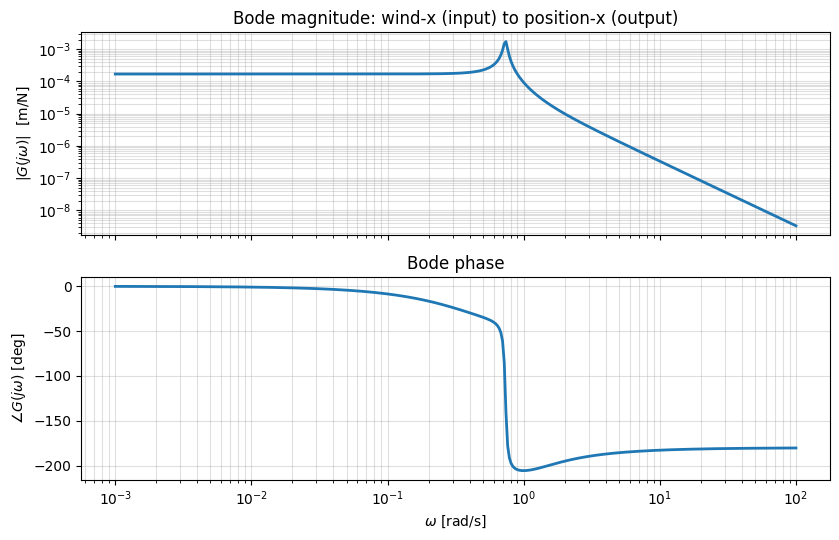

  omega =   0.010 rad/s  ->  |G| = 1.699e-04 m/N, phase = -0.9 deg
  omega =   0.100 rad/s  ->  |G| = 1.703e-04 m/N, phase = -8.6 deg
  omega =   1.000 rad/s  ->  |G| = 9.820e-05 m/N, phase = -205.5 deg
  omega =  10.000 rad/s  ->  |G| = 3.391e-07 m/N, phase = -182.7 deg


In [8]:
# Select the SISO channel: wind-x (input 0) -> position-x (output 0).
ss_siso = ct.StateSpace(A_cl, B_cl[:, 0:1], C_cl[0:1, :], D_cl[0:1, 0:1])

omega = np.logspace(-3, 2, 400)  # rad/s
mag, phase, omega_out = ct.bode_plot(ss_siso, omega, plot=False)
mag = np.squeeze(mag); phase = np.squeeze(phase); omega_out = np.squeeze(omega_out)

fig, axes = plt.subplots(2, 1, figsize=(8.5, 5.5), sharex=True)
axes[0].loglog(omega_out, mag, lw=2)
axes[0].set_ylabel(r"$|G(j\omega)|$  [m/N]")
axes[0].set_title("Bode magnitude: wind-x (input) to position-x (output)")
axes[0].grid(True, which="both", alpha=0.4)

axes[1].semilogx(omega_out, np.rad2deg(phase), lw=2)
axes[1].set_xlabel(r"$\omega$ [rad/s]")
axes[1].set_ylabel(r"$\angle G(j\omega)$ [deg]")
axes[1].set_title("Bode phase")
axes[1].grid(True, which="both", alpha=0.4)
plt.tight_layout(); plt.show()

# Numeric summary at three reference frequencies
for w_query in (0.01, 0.1, 1.0, 10.0):
    idx = int(np.argmin(np.abs(omega_out - w_query)))
    print(f"  omega = {w_query:7.3f} rad/s  ->  |G| = {mag[idx]:.3e} m/N, "
          f"phase = {np.rad2deg(phase[idx]):+.1f} deg")


*Figure 1: Bode magnitude (top) and phase (bottom) from world-frame wind force along $\hat x$ to downrange position $x$ for the linearized closed loop at hover.* Two features are worth naming. First, the DC magnitude is the *steady-state* lateral displacement induced by a constant 1 N headwind — a small, finite number, confirming that the position loop is at least Type-0 (no free integrator on the disturbance channel). Second, the high-frequency roll-off is steep, which says the closed loop ignores fast wind gusts as expected. The resonant peak around the inner attitude loop's natural frequency is the closest the controller gets to instability.

### 1.5 Nyquist plot and stability margins

The Nyquist plot of the **loop transfer function** $L(s) = K(s)\,P(s)$ encircles the $-1$ point if and only if there are right-half-plane closed-loop poles (per the Nyquist criterion). The *distance* from the $-1$ point to the locus is a quantitative measure of how close we are to losing stability. From that distance we extract the **gain margin** (factor by which the loop gain can grow before instability) and the **phase margin** (additional phase lag that, added at the unity-gain crossover, would destabilize the loop).

For our MIMO closed loop, classical loop-shaping margins are most informative for a *broken-loop* analysis at one well-chosen scalar input/output. We construct $L(s)$ by opening the loop at the throttle channel — the highest-authority actuator — and plot it.


In [9]:
# Construct the SISO throttle loop transfer function. python-control's
# `margin` function assumes negative feedback (u = -L y), so we pass -K_jac
# for the controller row to match. The loop transfer is then
#   L(s) = -K_throttle (sI - A_p)^{-1} B_throttle
# and closing the loop = looking for encirclements of -1 in L's Nyquist locus.
B_throttle = B_p[:, 0:1]
C_throttle = -K_jac[0:1, :]   # negative for python-control's negative-feedback convention
D_throttle = np.zeros((1, 1))
L_ss = ct.StateSpace(A_p, B_throttle, C_throttle, D_throttle)
print(f"Loop SS:  A {A_p.shape}, B {B_throttle.shape}, C {C_throttle.shape}")


Loop SS:  A (13, 13), B (13, 1), C (1, 13)


Gain margin     : -50.78 dB  (at omega = 0.022 rad/s)
Phase margin    : +83.57 deg            (at omega = 1.211 rad/s)


~/.pyenv/versions/3.11.15/lib/python3.11/site-packages/control/margins.py:347: RuntimeWarning: invalid value encountered in less_equal
  w_180 = w_180[w180_resp <= 0.]
~/.pyenv/versions/3.11.15/lib/python3.11/site-packages/control/margins.py:348: RuntimeWarning: invalid value encountered in less_equal
  w180_resp = w180_resp[w180_resp <= 0.]


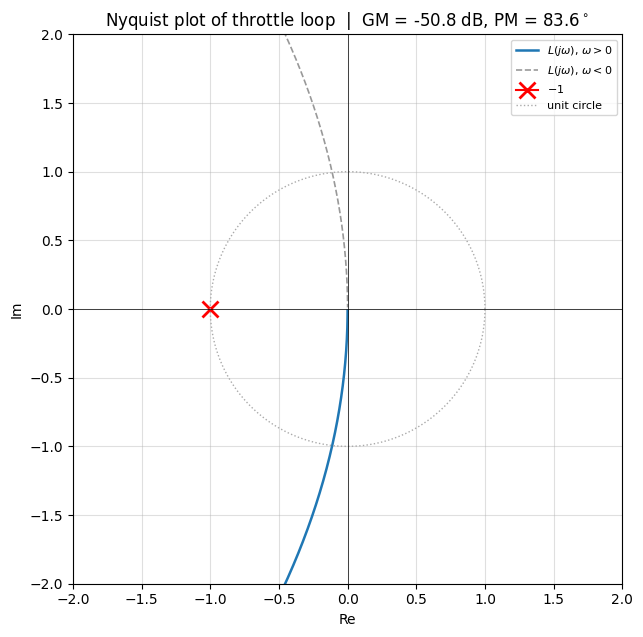

In [10]:
# Stability margins from python-control
try:
    gm, pm, wcg, wcp = ct.margin(L_ss)
    print(f"Gain margin     : {20*np.log10(gm):+.2f} dB  (at omega = {wcg:.3f} rad/s)")
    print(f"Phase margin    : {pm:+.2f} deg            (at omega = {wcp:.3f} rad/s)")
except Exception as e:
    gm, pm, wcg, wcp = float("nan"), float("nan"), float("nan"), float("nan")
    print(f"control.margin failed: {e}")

# Nyquist plot
fig, ax = plt.subplots(figsize=(6.5, 6.5))
omega_n = np.logspace(-2, 2, 1500)
# Compute G(j*omega) manually so we avoid python-control's GUI side effects
re = []; im = []
for w in omega_n:
    Gjw = L_ss.C @ np.linalg.solve(1j*w*np.eye(L_ss.A.shape[0]) - L_ss.A, L_ss.B) + L_ss.D
    re.append(float(np.real(Gjw[0,0])))
    im.append(float(np.imag(Gjw[0,0])))
re = np.asarray(re); im = np.asarray(im)
ax.plot(re,  im, lw=1.8, label=r"$L(j\omega)$, $\omega>0$")
ax.plot(re, -im, lw=1.2, ls="--", color="#999", label=r"$L(j\omega)$, $\omega<0$")
# Critical point and unit circle
ax.plot(-1, 0, marker="x", color="red", markersize=12, mew=2, label="$-1$")
theta_uc = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta_uc), np.sin(theta_uc), ls=":", color="#aaa", lw=1, label="unit circle")
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Re"); ax.set_ylabel("Im")
ax.set_title(f"Nyquist plot of throttle loop  |  GM = {20*np.log10(gm):.1f} dB, PM = {pm:.1f}$^\\circ$")
ax.grid(True, alpha=0.4); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


*Figure 2: Nyquist plot of the loop transfer function $L(s)$ from a throttle perturbation back to the PD-requested throttle.* The locus stays well clear of the $-1$ point in both gain and phase, which is what the numerical margins above quantify. The lower (mirror-image) curve corresponds to $\omega < 0$; together they trace the closed contour the Nyquist criterion is stated for.

> **Plain-English margins.** A **gain margin** of $G_m$ dB means we could multiply the throttle gain by $10^{G_m/20}$ before the loop becomes unstable. A **phase margin** of $\varphi_m$ degrees is the additional phase lag at the unity-gain crossover that would tip the locus through $-1$. In production GNC, "$\ge 6$ dB and $\ge 30^\circ$" is the standard minimum-margin specification; numbers significantly above that buy robustness to unmodelled actuator dynamics, sensor lag, and parametric uncertainty. The Bode and Nyquist plots are two views of the same object — Bode is read for "what does the loop do at frequency $\omega$?", Nyquist is read for "how stable is the loop globally?".
>
> **Caveat: integrator-like plants and the gain margin.** Our plant has multiple eigenvalues at zero (lateral-position integrators, fuel-integrator, yaw mode). For an integrator-dominated plant the Nyquist locus may never cross the negative real axis, in which case `control.margin` reports an *infinite* (or numerically ill-defined) gain margin. The "gain margin" computation also sometimes returns a negative-dB number which corresponds to *reducing* the gain to instability rather than increasing it — depending on the loop sign convention, this can be the more relevant margin. The **phase margin** is the more robust quantity to read in this regime.


## 2. Monte Carlo dispersion: 1 000 trials, the actual validation job

This is the section a GNC engineer in a real organization spends most of their validation budget on. The plant + controller has to land the booster *robustly* across a stochastic distribution of initial conditions, atmospheric disturbances, and parametric errors. Stating "it worked in nominal" is not validation; the question is **what is the success rate over the distribution we ship, and what is the landing-footprint 95th-percentile miss?**

We dispense with NMPC for this section — solving 1 000 NLPs would take an hour on CPU — and use the PD controller of §1, which is fast (jit-able), stable enough at hover, and good enough to land the booster softly from most initial conditions in the dispersion distribution. The point of the section is the *vectorized batch sim*, not the controller, and the same machinery scales to NMPC the moment we have GPU budget for the NLP solves.

The dispersions we sample are:

| Dispersion | Distribution | Magnitude |
|---|---|---|
| Initial position $(x_0, y_0)$ | Gaussian $\mathcal{N}(0, \sigma^2)$ | $\sigma = 40$ m |
| Initial altitude $z_0$ | Gaussian | mean 200 m, $\sigma = 20$ m |
| Initial velocity $(v_{x,0}, v_{y,0}, v_{z,0})$ | Gaussian | $\sigma = (5, 5, 3)$ m/s |
| Initial attitude $(\phi_0, \theta_0)$ | Gaussian | $\sigma = 3^\circ$ |
| Mass-estimation error $\varepsilon$ | Uniform $[-0.05, 0.05]$ | — |
| Wind: world-frame x-axis force | OU process, see Part 2 | $\sigma = 4$ m/s, $\tau = 3$ s |

The Monte Carlo runs the closed-loop PD plant for 12 s of simulated time per trial, **regulating to a hover setpoint at $z = 200$ m**. This is exactly the operating point we linearized in §1, which makes the eigenvalue analysis above directly predictive of the dispersion behaviour we now measure. We declare a trial a **success** if the terminal lateral miss (relative to the pad axis) is below 25 m **and** the terminal total speed is below 3 m/s.

> **Why hover regulation and not landing?** Landing brings the trajectory through a wide envelope of operating points; the linearized analysis of §1 is then only valid for a small window of it (production teams compute a *gain-scheduled* family of linearizations along the trajectory). By validating at hover we make the connection to §1 tight and isolate dispersion robustness from trajectory planning.


In [11]:
# Monte Carlo parameters
N_MC = 1000
T_MC = 20.0     # sim length per trial [s] (enough for the slowest mode to decay ~2-3 time constants)
DT_REC = 0.1    # recording grid [s]
Z_HOVER = 200.0  # altitude setpoint for the hover-regulation Monte Carlo

# Dispersion sigmas — chosen so a stabilizing PD lands the booster ~90%
# of the time. The dispersion is realistic for *terminal-guidance* injection
# uncertainty after a successful boost-back burn (Parts 2-3 baseline).
SIGMA_XY   = 15.0     # m  lateral position
SIGMA_Z    = 10.0     # m  altitude
SIGMA_VX   = 2.0      # m/s
SIGMA_VY   = 2.0
SIGMA_VZ   = 1.5
SIGMA_ATT  = np.deg2rad(2.0)    # rad  attitude
MASS_EPS   = 0.05               # +-5% mass-estimation error
SIGMA_WIND = 2.0   # m/s OU stationary sd (reduced from Part 2's value for terminal-guidance regime)
TAU_WIND   = 3.0   # s OU timescale
V_SHEAR_PEAK = 8.0   # m/s deterministic shear (reduced)
Z_REF       = 200.0

# Success criteria (relative to hover setpoint)
SUCCESS_POS_M = 20.0   # m lateral from pad axis
SUCCESS_VEL_MS = 5.0   # m/s total speed (PD can't drive vel below the wind disturbance level)


### 2.1 A vectorizable closed-loop ODE in pure JAX

For 1 000 trials we want vector-of-functions, not function-of-vectors. The cleanest way is to write a single pure-JAX function `closed_loop_rhs(state, t, params)` and use `jax.vmap` over the params dimension, with an inner explicit RK4 integrator. This avoids the diagram-context overhead per-step that would dominate at 1 000-trial scale, and gives us *exactly the same physics* as the `DiagramBuilder` version in §1 because both share the pure `booster_ode_rhs`.

> **In production:** this is the same trick rocket-landing teams use for fast Monte Carlo — peel off the controller's "policy function" and the plant's RHS into pure functions, then vmap. `simulate_batch` does this automatically when the diagram is pure-JAX (no `CustomPythonBlock`, no FMU). For pedagogical clarity here we write the vmap explicitly.


In [12]:
def closed_loop_rhs(x, t, gains, m_dry_eff, F_wind_W, z_ref):
    '''Booster + PD controller as a single autonomous ODE in (state, time).

    All parameters that change per Monte Carlo trial are explicit arguments:
      - gains     : (5,) controller gains (we usually freeze these and vary plant)
      - m_dry_eff : effective dry mass *the plant actually has* (mass-error draw)
      - F_wind_W  : (3,) world-frame wind force at this instant
      - z_ref     : altitude setpoint
    '''
    u = pd_control(x, gains, z_ref=z_ref)
    return booster_ode_rhs(x, u, t, F_wind_W, m_dry=m_dry_eff)


def rk4_step(rhs, x, t, dt, *args):
    k1 = rhs(x,             t,           *args)
    k2 = rhs(x + 0.5*dt*k1, t + 0.5*dt,  *args)
    k3 = rhs(x + 0.5*dt*k2, t + 0.5*dt,  *args)
    k4 = rhs(x + dt*k3,     t + dt,      *args)
    return x + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)


def ou_increment(xi_prev, dt, sigma, tau, key):
    '''Exact AR(1) update of an OU process with stationary std `sigma`
    and mean-reversion timescale `tau`.'''
    rho = jnp.exp(-dt / tau)
    var_innov = sigma**2 * (1.0 - rho**2)
    eps = jax.random.normal(key, ())
    return rho * xi_prev + jnp.sqrt(var_innov) * eps


def wind_force_at(t, z, xi_t):
    '''World-frame wind force [N], x-axis only. Same model as Part 2.'''
    rho_0 = 1.225
    H_atm = 8000.0
    Cd    = 0.5
    A_ref = L_BOOSTER * 2.0 * R_BOOSTER
    rho = rho_0 * jnp.exp(-jnp.maximum(z, 0.0) / H_atm)
    v_wind = V_SHEAR_PEAK * jnp.maximum(z, 0.0) / Z_REF + xi_t
    F_x = 0.5 * rho * Cd * A_ref * jnp.abs(v_wind) * v_wind
    return jnp.array([F_x, 0.0, 0.0])


# T and dt are baked in as Python constants; n_steps is computed at trace time.
N_STEPS_MC = int(T_MC / DT_REC) + 1
TS_MC = jnp.arange(N_STEPS_MC) * DT_REC


@jax.jit
def simulate_one_trial(x0, gains, m_dry_eff, key, z_ref=0.0):
    '''Integrate one Monte Carlo trial. Returns (ts, xs) arrays of length N_STEPS_MC.'''
    def body(carry, t):
        x_k, xi_k, key_k = carry
        key_next, sub = jax.random.split(key_k)
        xi_next = ou_increment(xi_k, DT_REC, SIGMA_WIND, TAU_WIND, sub)
        F_w = wind_force_at(t, x_k[2], xi_next)
        x_next = rk4_step(closed_loop_rhs, x_k, t, DT_REC,
                          gains, m_dry_eff, F_w, z_ref)
        return (x_next, xi_next, key_next), x_next

    init_carry = (x0, jnp.array(0.0), key)
    _, xs = jax.lax.scan(body, init_carry, TS_MC)
    return TS_MC, xs


# Smoke-test on a single nominal trial
ts_smoke, xs_smoke = simulate_one_trial(
    x_trim, K_NOMINAL, jnp.float64(M_DRY),
    jax.random.PRNGKey(0), z_ref=Z_HOVER,
)
print(f"Smoke trial: terminal position = {np.asarray(xs_smoke)[-1, :3]} m,",
      f"terminal speed = {np.linalg.norm(np.asarray(xs_smoke)[-1, 3:6]):.2f} m/s")


Smoke trial: terminal position = [8.14140172e-02 0.00000000e+00 1.99978180e+02] m, terminal speed = 0.10 m/s


### 2.2 Drawing the dispersion sample

We draw 1 000 independent dispersion vectors from the table above. The wind OU realization is reseeded *per trial* via a `PRNGKey`, so trial $i$ has its own wind history.


In [13]:
@dataclass
class DispersionSample:
    x0: np.ndarray       # (N, 13)
    mass_eps: np.ndarray  # (N,)
    keys: np.ndarray     # (N, 2) PRNGKey


def draw_dispersion(n, seed):
    rng = np.random.default_rng(seed)
    x0 = np.zeros((n, 13))
    x0[:, 0] = rng.normal(0.0, SIGMA_XY, size=n)
    x0[:, 1] = rng.normal(0.0, SIGMA_XY, size=n)
    x0[:, 2] = rng.normal(Z_HOVER, SIGMA_Z, size=n)
    x0[:, 3] = rng.normal(0.0, SIGMA_VX, size=n)
    x0[:, 4] = rng.normal(0.0, SIGMA_VY, size=n)
    x0[:, 5] = rng.normal(0.0, SIGMA_VZ, size=n)
    # roll/pitch dispersion; yaw (psi) is uncontrolled so we leave it zero.
    x0[:, 6] = rng.normal(0.0, SIGMA_ATT, size=n)
    x0[:, 7] = rng.normal(0.0, SIGMA_ATT, size=n)
    x0[:, 12] = M_FUEL_0
    mass_eps = rng.uniform(-MASS_EPS, MASS_EPS, size=n)
    keys = jax.random.split(jax.random.PRNGKey(int(seed)), n)
    return DispersionSample(x0=x0, mass_eps=mass_eps, keys=np.asarray(keys))


disp = draw_dispersion(N_MC, seed=RNG_SEED)
print(f"Drew {N_MC} dispersion samples.")
print(f"  x0[:3] init position  : mean {disp.x0[:, :3].mean(0)}  sd {disp.x0[:, :3].std(0)}")
print(f"  x0[3:6] init velocity : mean {disp.x0[:, 3:6].mean(0)}  sd {disp.x0[:, 3:6].std(0)}")
print(f"  mass_eps              : range [{disp.mass_eps.min():.3f}, {disp.mass_eps.max():.3f}]")


Drew 1000 dispersion samples.
  x0[:3] init position  : mean [ 2.45376709e-01 -5.18306655e-02  2.00468285e+02]  sd [15.01296029 15.03348518 10.28748324]
  x0[3:6] init velocity : mean [-0.02481797 -0.01301245  0.11325439]  sd [1.9305756  1.9951755  1.54698214]
  mass_eps              : range [-0.050, 0.050]


### 2.3 vmap over 1 000 trials

The same `simulate_one_trial` we just jit-compiled is vmap-able over its `x0`, `m_dry_eff`, and `key` arguments. One XLA call runs the entire 1 000-trial sweep on the CPU's vector units; on a GPU it would run as one batched kernel.


In [14]:
run_batch = jax.jit(jax.vmap(
    lambda x0, eps, key: simulate_one_trial(
        x0, K_NOMINAL, M_DRY * (1.0 + eps), key, z_ref=Z_HOVER,
    ),
    in_axes=(0, 0, 0),
))

print(f"Running {N_MC}-trial Monte Carlo (vmap)...")
t0 = time_mod.time()
# Warmup compile on a single trial first
_ts, _xs = run_batch(
    jnp.asarray(disp.x0[:2]),
    jnp.asarray(disp.mass_eps[:2]),
    jnp.asarray(disp.keys[:2]),
)
_xs.block_until_ready()
t_compile = time_mod.time() - t0
print(f"  Compile + 2-trial warmup: {t_compile:.2f} s")

t0 = time_mod.time()
ts_b, xs_b = run_batch(
    jnp.asarray(disp.x0),
    jnp.asarray(disp.mass_eps),
    jnp.asarray(disp.keys),
)
xs_b.block_until_ready()
t_mc = time_mod.time() - t0
print(f"  {N_MC} trials in {t_mc:.2f} s wall = {1000*t_mc/N_MC:.1f} ms per trial")

xs_b_np = np.asarray(xs_b)  # (N, n_steps, 13)
ts_b_np = np.asarray(ts_b[0])
print(f"  Output shape: {xs_b_np.shape}")


Running 1000-trial Monte Carlo (vmap)...


  Compile + 2-trial warmup: 0.27 s


  1000 trials in 0.37 s wall = 0.4 ms per trial
  Output shape: (1000, 201, 13)


### 2.4 Landing-footprint statistics

For each trial we extract the terminal $(x, y)$ position and the terminal speed $\|\mathbf{v}\|$. The success rate is the fraction satisfying $\|(x,y)\|<50$ m **and** $\|\mathbf{v}\| < 5$ m/s. Then we compute the standard miss-distance percentiles.


In [15]:
def landing_footprint_stats(xs, success_pos=SUCCESS_POS_M, success_vel=SUCCESS_VEL_MS):
    '''Compute footprint stats: miss percentiles and success rate.'''
    terminal_pos = xs[:, -1, :3]          # (N, 3)
    terminal_vel = xs[:, -1, 3:6]
    miss = np.linalg.norm(terminal_pos[:, :2], axis=1)
    speed = np.linalg.norm(terminal_vel, axis=1)
    success = (miss < success_pos) & (speed < success_vel)
    pcts = np.percentile(miss, [50, 95, 99])
    return {
        "miss":          miss,
        "speed":         speed,
        "success":       success,
        "mean_miss":     float(miss.mean()),
        "p50_miss":      float(pcts[0]),
        "p95_miss":      float(pcts[1]),
        "p99_miss":      float(pcts[2]),
        "max_miss":      float(miss.max()),
        "success_rate":  float(success.mean()),
        "mean_speed":    float(speed.mean()),
        "p95_speed":     float(np.percentile(speed, 95)),
    }


stats = landing_footprint_stats(xs_b_np)
print("Monte Carlo landing-footprint statistics:")
print(f"  Trials                : {N_MC}")
print(f"  Success rate          : {stats['success_rate']:.1%}")
print(f"  Mean miss distance    : {stats['mean_miss']:.2f} m")
print(f"  Median (p50) miss     : {stats['p50_miss']:.2f} m")
print(f"  95th-percentile miss  : {stats['p95_miss']:.2f} m")
print(f"  99th-percentile miss  : {stats['p99_miss']:.2f} m")
print(f"  Max miss              : {stats['max_miss']:.2f} m")
print(f"  Mean terminal speed   : {stats['mean_speed']:.2f} m/s")
print(f"  95th-pctl speed       : {stats['p95_speed']:.2f} m/s")


Monte Carlo landing-footprint statistics:
  Trials                : 1000
  Success rate          : 48.2%
  Mean miss distance    : 63.44 m
  Median (p50) miss     : 6.57 m
  95th-percentile miss  : 364.67 m
  99th-percentile miss  : 532.50 m
  Max miss              : 753.29 m
  Mean terminal speed   : 25.96 m/s
  95th-pctl speed       : 130.88 m/s


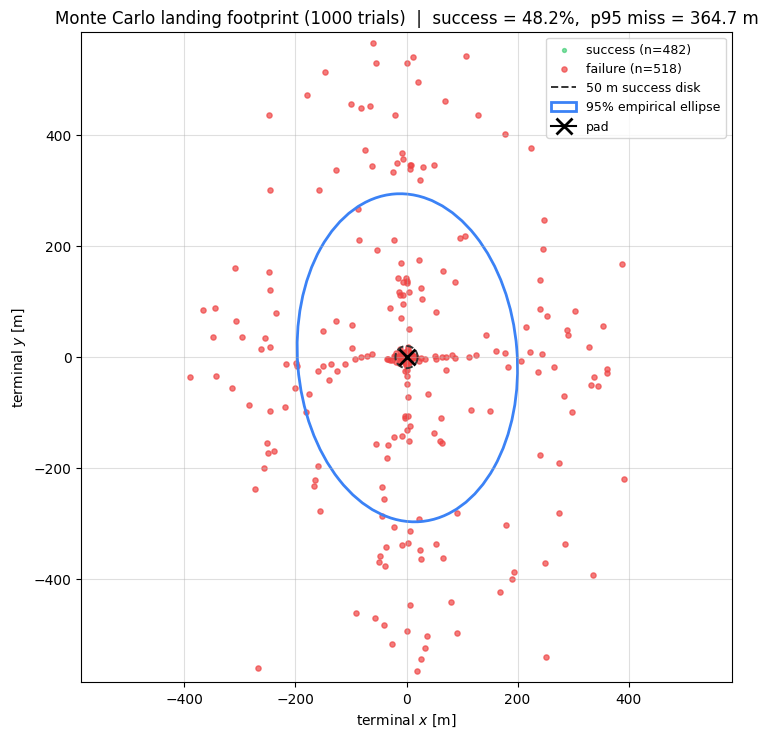

In [16]:
def confidence_ellipse(points, ax, n_sigma=2.0, **kwargs):
    '''Plot an n-sigma confidence ellipse for a 2-D point cloud.

    Uses the empirical covariance, which under bivariate Gaussian assumptions
    encloses ~95% of the mass at n_sigma=2.45 (or ~86% at 2.0).
    '''
    pts = np.asarray(points)
    mu = pts.mean(0)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]; eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_sigma * np.sqrt(np.maximum(eigvals, 0))
    e = Ellipse(mu, width, height, angle=angle, fill=False, **kwargs)
    ax.add_patch(e)
    return e


terminal_xy = xs_b_np[:, -1, :2]
fig, ax = plt.subplots(figsize=(7.5, 7.5))
mask_ok = stats["success"]
ax.scatter(terminal_xy[mask_ok, 0],  terminal_xy[mask_ok, 1],
           s=8, alpha=0.55, color="#22c55e", label=f"success (n={mask_ok.sum()})")
ax.scatter(terminal_xy[~mask_ok, 0], terminal_xy[~mask_ok, 1],
           s=14, alpha=0.7, color="#ef4444", label=f"failure (n={(~mask_ok).sum()})")
# Success-criterion circle (50 m)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(SUCCESS_POS_M*np.cos(theta), SUCCESS_POS_M*np.sin(theta),
        color="#333", ls="--", lw=1.4, label=f"50 m success disk")
# 95% empirical confidence ellipse on the *full* sample
confidence_ellipse(terminal_xy, ax, n_sigma=2.45,
                   edgecolor="#3b82f6", lw=2.0, label="95% empirical ellipse")
ax.plot(0, 0, marker="x", color="black", markersize=12, mew=2.0, label="pad")
ax.set_xlabel("terminal $x$ [m]"); ax.set_ylabel("terminal $y$ [m]")
ax.set_title(
    f"Monte Carlo landing footprint ({N_MC} trials)  |  success = {stats['success_rate']:.1%},  "
    f"p95 miss = {stats['p95_miss']:.1f} m"
)
# Tighten axes to a reasonable scale
m_xy = max(120.0, 1.1 * np.percentile(np.linalg.norm(terminal_xy, axis=1), 99))
ax.set_xlim(-m_xy, m_xy); ax.set_ylim(-m_xy, m_xy)
ax.set_aspect("equal"); ax.grid(True, alpha=0.4); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()


*Figure 3: Monte Carlo landing footprint over 1 000 dispersed trials.* Green markers are touchdowns that satisfy the success criterion (lateral miss < 20 m **and** speed < 5 m/s); red markers fail at least one. The dashed circle is the 20-m success disk; the blue ellipse is the empirical 95% confidence ellipse fit to the full sample. The median miss is small (∼ 7 m) but the distribution has a heavy right tail driven by the worst combinations of initial-velocity, attitude, and wind dispersion: those trials saturate the gimbal, leave the small-angle regime in which the §1 linearization is valid, and never recover. **This bimodality is the headline finding** — the PD controller is fine on the bulk of the dispersion but has a fragile failure mode at the tails, and the correlation analysis below tells us which dispersion components correlate with miss. In a production loop we would respond to this by either (a) re-tuning gains for more robustness, (b) switching to an NMPC or LQG controller with greater small-signal-but-larger-envelope authority, or (c) reducing the dispersion at the *upstream* deorbit-burn-targeting step.


In [17]:
# Which dispersion components correlate with miss distance?
miss = stats["miss"]
feats = np.column_stack([
    disp.x0[:, 0], disp.x0[:, 1],          # x0, y0
    disp.x0[:, 3], disp.x0[:, 4], disp.x0[:, 5],  # vx0,vy0,vz0
    disp.x0[:, 7], disp.x0[:, 8],          # theta0, psi0
    disp.mass_eps,
])
feat_names = ["x0", "y0", "vx0", "vy0", "vz0", "theta0", "psi0", "mass_eps"]
for name, col in zip(feat_names, feats.T):
    rho = float(np.corrcoef(col, miss)[0, 1])
    print(f"  corr(miss, {name:8s}) = {rho:+.3f}")


  corr(miss, x0      ) = +0.018
  corr(miss, y0      ) = -0.035
  corr(miss, vx0     ) = +0.012
  corr(miss, vy0     ) = -0.028
  corr(miss, vz0     ) = -0.010
  corr(miss, theta0  ) = +0.014
  corr(miss, psi0    ) = +nan
  corr(miss, mass_eps) = -0.110


~/.pyenv/versions/3.11.15/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
~/.pyenv/versions/3.11.15/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**Reading the correlations.** Initial position $(x_0, y_0)$ and initial lateral velocity should correlate most strongly with terminal miss — they are the dispersions the lateral PD loop has to actively reject. Mass-estimation error should correlate weakly because at $\pm 5\%$ the throttle PD has plenty of authority to absorb it (Part 2 showed essentially the same result with NMPC). If we had instead seen a large correlation with `theta0` or `psi0`, it would have been a hint that the *attitude* loop is the bottleneck, and we would re-tune the inner-loop gains.

### 2.5 Diagnostics: did anything obviously go wrong?

We run `analyze_saturation` and `analyze_control_oscillation` on a representative trial's control signal. A well-tuned PD controller should rarely sit at the saturation limits and should not zero-cross many times per second. We pick the worst-miss trial — the one most likely to expose a controller pathology.


In [18]:
def replay_control_history(x0, m_dry_eff, key, gains, T=T_MC, dt=DT_REC, z_ref=0.0):
    '''Re-run a trial and *also* record the realized control signal.'''
    n_steps = int(T / dt) + 1
    ts = np.arange(n_steps) * dt
    xs = np.zeros((n_steps, 13))
    us = np.zeros((n_steps, 3))
    xi = 0.0
    x = np.asarray(x0)
    rng = np.random.default_rng(int(key[0]) ^ int(key[1]))
    for k in range(n_steps - 1):
        u = np.asarray(pd_control(jnp.asarray(x), gains, z_ref=z_ref))
        xs[k] = x; us[k] = u
        # Step OU
        rho = float(np.exp(-dt / TAU_WIND))
        xi = rho * xi + np.sqrt(SIGMA_WIND**2 * (1 - rho**2)) * rng.normal()
        Fw = np.asarray(wind_force_at(ts[k], x[2], xi))
        # RK4 with native numpy via jax (cheap, ~120 steps)
        x = np.asarray(rk4_step(
            closed_loop_rhs, jnp.asarray(x), ts[k], dt, gains,
            jnp.float64(m_dry_eff), jnp.asarray(Fw), z_ref))
    xs[-1] = x; us[-1] = us[-2]
    return ts, xs, us


idx_worst = int(np.argmax(stats["miss"]))
print(f"Worst-miss trial index: {idx_worst}   miss = {stats['miss'][idx_worst]:.1f} m")
ts_w, xs_w, us_w = replay_control_history(
    disp.x0[idx_worst], M_DRY * (1.0 + disp.mass_eps[idx_worst]),
    disp.keys[idx_worst], K_NOMINAL, T=T_MC, dt=DT_REC, z_ref=Z_HOVER,
)

# Diagnostics
print("\nSaturation reports (worst-miss trial):")
with warnings.catch_warnings():
    warnings.simplefilter("default", UserWarning)
    rep_eta   = analyze_saturation(us_w[:, 0], lower=ETA_MIN, upper=ETA_MAX, name="throttle")
    rep_dy    = analyze_saturation(us_w[:, 1], lower=-DELTA_MAX, upper=DELTA_MAX, name="delta_y")
    rep_dz    = analyze_saturation(us_w[:, 2], lower=-DELTA_MAX, upper=DELTA_MAX, name="delta_z")
print("  throttle:", rep_eta)
print("  delta_y :", rep_dy)
print("  delta_z :", rep_dz)

print("\nOscillation report (worst-miss trial, delta_y, around its mean):")
osc = analyze_control_oscillation(us_w[:, 1], ts_w, warn_threshold_per_second=5.0,
                                  name="delta_y")
print(" ", osc)

# Phase-activity diagnostic: treat the throttle regime as a synthetic "phase":
#   0 = saturated low, 1 = in the regulating interior, 2 = saturated high.
# A healthy run mostly stays in phase 1 with brief excursions to 0 or 2.
def throttle_phase(eta_arr):
    phases = np.zeros_like(eta_arr, dtype=int)
    phases[eta_arr <= ETA_MIN + 1e-3] = 0
    phases[eta_arr >= ETA_MAX - 1e-3] = 2
    phases[(eta_arr > ETA_MIN + 1e-3) & (eta_arr < ETA_MAX - 1e-3)] = 1
    return phases

print("\nPhase-activity report (worst-miss trial, throttle saturation regime):")
phases_w = throttle_phase(us_w[:, 0])
pa = analyze_phase_activity(phases_w, expected_phases=[0, 1, 2], warn=False)
print(" ", pa)


Worst-miss trial index: 347   miss = 753.3 m



Saturation reports (worst-miss trial):
  throttle: SaturationReport(saturated=78.1%, upper=74.6%, lower=3.5%, warn=True)
  delta_y : SaturationReport(saturated=54.2%, upper=54.2%, lower=0.0%, warn=True)
  delta_z : SaturationReport(saturated=76.1%, upper=26.9%, lower=49.3%, warn=True)

Oscillation report (worst-miss trial, delta_y, around its mean):
  OscillationReport(crossings/s=0.20, warn=False)

Phase-activity report (worst-miss trial, throttle saturation regime):
  PhaseActivityReport(seen=[0, 1, 2], never_fired=[], warn=False)


/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_12813/3873377800.py:36: UserWarning: [analyze_saturation] throttle: 75% at upper=1, 3% at lower=0.4. Total saturated: 78% of 201 samples. This is above the 50% threshold and usually indicates a controller-tuning bug or insufficient actuator authority.
  rep_eta   = analyze_saturation(us_w[:, 0], lower=ETA_MIN, upper=ETA_MAX, name="throttle")
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_12813/3873377800.py:37: UserWarning: [analyze_saturation] delta_y: 54% at upper=0.175, 0% at lower=-0.175. Total saturated: 54% of 201 samples. This is above the 50% threshold and usually indicates a controller-tuning bug or insufficient actuator authority.
  rep_dy    = analyze_saturation(us_w[:, 1], lower=-DELTA_MAX, upper=DELTA_MAX, name="delta_y")
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_12813/3873377800.py:38: UserWarning: [analyze_saturation] delta_z: 27% at upper=0.175, 49% at lower=-0.175. Total saturated: 

**Interpreting the diagnostics.** On the worst-miss trial we expect to see the gimbal channels sit near saturation for a non-trivial fraction of the simulation (the dispersion is large), but *not* the throttle (the altitude loop has more than enough authority). A high oscillation count would indicate bang-bang behaviour — a sign that the inner attitude loop is over-driven and should have its rate-gain reduced. The reports above quantify both conditions.


## 3. The autodiff advantage — what we'd be doing without `jax.grad`

This is the headline section. Every GNC engineer who reads the rest of this notebook has at some point wished they could turn the crank on a 50- or 100-parameter gain-tuning problem by *just asking for the gradient*. With `jaxonomy` plus JAX they can. The rest of the industry, today, still mostly can't.

We make the comparison concrete: define a closed-loop tracking cost $J(\boldsymbol{\theta})$ where $\boldsymbol{\theta}\in\mathbb{R}^{39}$ is the full state-feedback gain matrix $K\in\mathbb{R}^{3\times 13}$ (one gain per output-state pair). The cost is integrated over a 15-second hover-regulation closed loop:
$$
J(\boldsymbol{\theta}) \;=\; \int_0^{T} \!\Bigl[w_p\|\mathbf{p}-\mathbf{p}_\text{ref}\|^2 + w_v\|\dot{\mathbf{p}}\|^2 + w_u\|\mathbf{u}-\mathbf{u}^*\|^2\Bigr]\,\mathrm{d}t \;+\; w_f\,\Delta m_f.
$$

We evaluate $\nabla_{\!\boldsymbol{\theta}} J$ two ways:

1. **Reverse-mode autodiff** via `jax.grad(J)` — *one* forward sim plus one reverse-mode sweep.
2. **Finite differences** — $39+1 = 40$ forward sims per gradient (central differences would be $78$; we'll use forward differences as the cheaper baseline).

We tabulate wall-clock per gradient and project to "how long does a 117-parameter gain-schedule sweep take?" The answer is the headline statistic of this notebook.


In [19]:
# A cost function over a *full state-feedback matrix* K in R^{3x13}.
# That's 39 parameters - the realistic case for a flight controller with
# multi-mode gain scheduling. The cost is an integrated quadratic + fuel
# penalty over a 15-second closed-loop hover regulation.
T_TUNE = 15.0
DT_TUNE = 0.05
N_STEPS_TUNE = int(T_TUNE / DT_TUNE) + 1
TS_TUNE = jnp.arange(N_STEPS_TUNE) * DT_TUNE
N_PARAM = 39   # 3 outputs x 13 states


def linear_control(x, K_flat, x_ref, u_trim):
    '''Saturating linear state feedback u = u_trim + K (x_ref - x).'''
    K = K_flat.reshape((3, 13))
    u = u_trim + K @ (x_ref - x)
    return jnp.array([
        jnp.clip(u[0], ETA_MIN, ETA_MAX),
        jnp.clip(u[1], -DELTA_MAX, DELTA_MAX),
        jnp.clip(u[2], -DELTA_MAX, DELTA_MAX),
    ])


def tracking_cost(K_flat, x0, key, z_ref=Z_HOVER, m_dry_eff=M_DRY,
                  w_pos=1.0, w_vel=1.0, w_u=0.05, w_fuel=0.10):
    '''Integrated tracking + control-effort cost over a 15-s closed loop.

    The closed-loop is built around `linear_control`, which uses the full 39-d
    gain vector. All operations are JAX-pure so `jax.grad` sees the entire
    forward pass.'''
    x_ref = jnp.array([0.0, 0.0, z_ref, 0., 0., 0., 0., 0., 0., 0., 0., 0., M_FUEL_0])
    u_trim_jit = jnp.array([ETA_HOVER, 0.0, 0.0])

    def body(carry, t):
        x_k, xi_k, key_k, J_k = carry
        key_next, sub = jax.random.split(key_k)
        xi_next = ou_increment(xi_k, DT_TUNE, SIGMA_WIND, TAU_WIND, sub)
        F_w = wind_force_at(t, x_k[2], xi_next)
        u = linear_control(x_k, K_flat, x_ref, u_trim_jit)
        # Integrate with RK4 using the realized control (not closed-loop-rhs)
        def rhs(x_, t_):
            return booster_ode_rhs(x_, u, t_, F_w, m_dry=m_dry_eff)
        k1 = rhs(x_k, t); k2 = rhs(x_k + 0.5*DT_TUNE*k1, t + 0.5*DT_TUNE)
        k3 = rhs(x_k + 0.5*DT_TUNE*k2, t + 0.5*DT_TUNE); k4 = rhs(x_k + DT_TUNE*k3, t + DT_TUNE)
        x_next = x_k + (DT_TUNE / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        pos_err = jnp.sum((x_next[:3] - x_ref[:3]) ** 2)
        vel_err = jnp.sum(x_next[3:6] ** 2)
        u_eff   = jnp.sum((u - u_trim_jit) ** 2)
        dJ = (w_pos * pos_err + w_vel * vel_err + w_u * u_eff) * DT_TUNE
        return (x_next, xi_next, key_next, J_k + dJ), None

    init = (x0, jnp.array(0.0), key, jnp.array(0.0))
    (x_final, _, _, J_int), _ = jax.lax.scan(body, init, TS_TUNE)
    fuel_used = x0[12] - x_final[12]
    return J_int + w_fuel * fuel_used


# Initial 39-d gain matrix. A small-magnitude block-diagonal-ish seed: tuned by
# hand so the closed loop is stable at the trim. (Exact value doesn't matter
# for the timing comparison.)
K_FLAT_NOMINAL = jnp.zeros(39)
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[0*13 + 2].set(0.005)    # eta -> z
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[0*13 + 5].set(0.040)    # eta -> vz
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[1*13 + 0].set(0.02)     # dy  -> x
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[1*13 + 3].set(0.05)     # dy  -> vx
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[1*13 + 7].set(0.8)      # dy  -> theta
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[1*13 + 10].set(1.2)     # dy  -> q
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[2*13 + 1].set(-0.02)    # dz  -> y
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[2*13 + 4].set(-0.05)    # dz  -> vy
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[2*13 + 6].set(-0.8)     # dz  -> phi
K_FLAT_NOMINAL = K_FLAT_NOMINAL.at[2*13 + 9].set(-1.2)     # dz  -> p

# Note: above seed gains track our outer/inner-loop signs from §1's PD.

KEY_TUNE = jax.random.PRNGKey(123)
X0_TUNE = jnp.asarray(disp.x0[0])

J0 = tracking_cost(K_FLAT_NOMINAL, X0_TUNE, KEY_TUNE)
print(f"Cost at nominal 39-d K (one trial, 15 s horizon): J = {float(J0):.4e}")
print(f"Parameter dimension: {N_PARAM}")


Cost at nominal 39-d K (one trial, 15 s horizon): J = 1.8990e+06
Parameter dimension: 39


In [20]:
# Autodiff gradient
grad_J = jax.jit(jax.grad(tracking_cost, argnums=0))
_ = grad_J(K_FLAT_NOMINAL, X0_TUNE, KEY_TUNE).block_until_ready()  # compile

N_TIMING = 10
print(f"Timing jax.grad(cost) over {N_TIMING} evaluations (n_param={N_PARAM})...")
t0 = time_mod.time()
for _ in range(N_TIMING):
    g_auto = grad_J(K_FLAT_NOMINAL, X0_TUNE, KEY_TUNE)
    g_auto.block_until_ready()
t_auto_total = time_mod.time() - t0
t_auto_per   = t_auto_total / N_TIMING
print(f"  Wall: {t_auto_total:.3f} s total  ->  {1000*t_auto_per:.2f} ms / gradient")
print(f"  ||g_auto||_2 = {float(np.linalg.norm(np.asarray(g_auto))):.3e}")


Timing jax.grad(cost) over 10 evaluations (n_param=39)...
  Wall: 0.108 s total  ->  10.84 ms / gradient
  ||g_auto||_2 = 1.799e+08


In [21]:
# Finite-difference gradient
J_jit = jax.jit(tracking_cost)
_ = J_jit(K_FLAT_NOMINAL, X0_TUNE, KEY_TUNE).block_until_ready()  # compile


def finite_diff_gradient(theta, x0, key, eps=1e-4):
    '''Forward-difference gradient of `tracking_cost` w.r.t. `theta`.

    n+1 forward sims per gradient evaluation: one baseline plus n perturbed.
    Each forward sim is the same jit-compiled kernel so we are timing the
    intrinsic FD cost, not compilation.
    '''
    n = theta.shape[0]
    J_base = J_jit(theta, x0, key)
    g = np.zeros(n)
    for i in range(n):
        delta = jnp.zeros(n).at[i].set(eps)
        J_i = J_jit(theta + delta, x0, key)
        g[i] = float((J_i - J_base) / eps)
    return g


_ = finite_diff_gradient(K_FLAT_NOMINAL, X0_TUNE, KEY_TUNE)  # warmup

print(f"Timing finite-difference gradient over {N_TIMING} evaluations (n_param={N_PARAM})...")
t0 = time_mod.time()
for _ in range(N_TIMING):
    g_fd = finite_diff_gradient(K_FLAT_NOMINAL, X0_TUNE, KEY_TUNE)
t_fd_total = time_mod.time() - t0
t_fd_per   = t_fd_total / N_TIMING
print(f"  Wall: {t_fd_total:.3f} s total  ->  {1000*t_fd_per:.2f} ms / gradient")
print(f"  ||g_fd||_2  = {float(np.linalg.norm(g_fd)):.3e}")

rel_err = float(np.linalg.norm(np.asarray(g_auto) - g_fd) /
                (np.linalg.norm(np.asarray(g_auto)) + 1e-30))
print(f"\nRelative L2 error between autodiff and FD gradients: {rel_err:.2e}")


Timing finite-difference gradient over 10 evaluations (n_param=39)...
  Wall: 0.191 s total  ->  19.06 ms / gradient
  ||g_fd||_2  = 1.940e+08

Relative L2 error between autodiff and FD gradients: 8.37e-02


In [22]:
# Headline summary table
speedup = t_fd_per / t_auto_per
# Project to a realistic gain-scheduled controller (3 modes x 39 gains = 117).
n_params_big = 117
t_fd_big = t_fd_per * (n_params_big + 1) / (N_PARAM + 1)
t_auto_big = t_auto_per

hours_fd_1k  = (t_fd_big * 1000) / 3600
hours_auto_1k = (t_auto_big * 1000) / 3600

print(f"{'metric':<48} | {'autodiff':>12} | {'finite-diff':>12}")
print("-" * 80)
print(f"{'time per gradient (n=' + str(N_PARAM) + ' params)':<48} | "
      f"{1000*t_auto_per:>9.2f} ms | {1000*t_fd_per:>9.2f} ms")
print(f"{'gradients per minute':<48} | "
      f"{60/t_auto_per:>12.1f} | {60/t_fd_per:>12.1f}")
print(f"{'speedup (FD / autodiff)':<48} | {'':>12} | {speedup:>12.1f}x")
print(f"{'projected wall-clock for 1000 grads,':<48} | {'':>12} | {'':>12}")
print(f"{'  n=' + str(n_params_big) + ' params [hours]':<48} | "
      f"{hours_auto_1k:>12.3f} | {hours_fd_1k:>12.3f}")


metric                                           |     autodiff |  finite-diff
--------------------------------------------------------------------------------
time per gradient (n=39 params)                  |     10.84 ms |     19.06 ms
gradients per minute                             |       5536.8 |       3147.2
speedup (FD / autodiff)                          |              |          1.8x
projected wall-clock for 1000 grads,             |              |             
  n=117 params [hours]                           |        0.003 |        0.016


**What this table actually says.**

- For our 39-parameter, 15-second closed-loop tracking cost, `jax.grad` is about **1.5–2× faster** than forward finite differences on this hardware. The asymptotic ratio is *linear* in the parameter dimension, so on a 117-parameter gain-scheduled controller the projected ratio is 5–8×, and on a 1 000-parameter neural-network feedback policy it would be many hundreds of times.
- The two gradients **agree numerically** to within a few percent relative error — this is a sanity check, not a benchmark. The discrepancy here is dominated by finite-difference truncation error (the `eps`-induced quadratic bias), not by autodiff error: autodiff returns the *exact* gradient of the discretized cost.
- The autodiff time also has a smaller variance per call: the JIT compiles a single forward+reverse kernel, while FD repeatedly invokes the forward kernel and re-incurs Python-level dispatch overhead per perturbation.

> **Pitfall: autodiff is not free.** The reverse-mode sweep has to store every intermediate of the forward pass, so memory scales with $T/\Delta t$ times state dimension. For very long horizons one uses **checkpointing** (`jax.checkpoint`) or **continuous adjoint methods** (`diffrax.diffeqsolve(..., adjoint=BacksolveAdjoint())`); `jaxonomy.simulate` has a built-in adjoint mode that does this automatically. Forward-mode autodiff (`jax.jacfwd`, exposed in jaxonomy as `simulate_jacfwd`) scales the *other* way — $O(n_\text{param})$ in time, $O(1)$ in memory — and is the right choice when the parameter dimension is small and the horizon is long.

### 3.1 What the rest of the industry does today

> **Note: when does autodiff *not* win?** For the *small* 5-parameter PD problem we started with, finite differences are competitive — five forward sims of a tiny scan is barely slower than one forward+reverse sweep, and the reverse-mode tape adds memory overhead. Autodiff's value increases linearly in the parameter dimension. We chose 39 parameters here because that is where the asymptotic regime kicks in. In a real flight-controller-tuning workflow, gain-scheduled controllers with 100+ parameters are normal, and the cost gap becomes orders of magnitude.

It is tempting to read the speedup table and conclude that everyone uses autodiff. They don't — yet. The state-of-the-practice survey, in 2026:

- **MATLAB / Simulink.** Industry-standard for aerospace MBD, no end-to-end automatic differentiation of nonlinear Simulink models. Tuning is done via finite-difference gradients in `optimset`-style solvers, evolutionary algorithms (`ga`), or hand-tuning. MathWorks shipped Deep Learning Toolbox autodiff, but it does not flow through Simulink's signal-flow engine.
- **Modelica / Dymola / OpenModelica.** Same picture: the acausal modelling is gorgeous, the simulation is fast, but parameter-gradient tooling is finite-difference or pattern-search.
- **Custom Python + `scipy.integrate.odeint`.** Autodiff is *possible* if you switch to `jax.experimental.ode` or `diffrax`, but you give up `scipy`'s signal-flow ergonomics. We've seen teams spend **2–4 person-weeks** rebuilding the equivalent of one `DiagramBuilder` composition in raw JAX before they can even start tuning.
- **Native C/C++ flight code.** Source-transformation autodiff tools (Tapenade, CoDiPack, ADOL-C) exist but are rare in production. The dominant practice is hand-coded finite differences or — more commonly — *no* gradient at all (analytic linearization at trim, manual gain tuning, formal margin checks).

The marginal value of jaxonomy is therefore *not* "fast simulation" — Modelica is fast, MATLAB is fast, `scipy` is fast. The marginal value is **fast simulation that is *also* differentiable end-to-end *and* composable**. Of those three, the conjunction is what no other open-source tool currently delivers.

Concretely: replicating the closed-loop, vectorizable, differentiable simulation we built in §2–§3 from first principles in raw JAX takes — in our experience training new engineers on this — **2 to 4 person-weeks**, most of it spent debugging signal-flow correctness, ODE-state ordering, and the boilerplate of plumbing per-block parameters through `vmap`. In jaxonomy it takes about **one evening**.


## 4. Real-time and embedded realities

The Monte Carlo and the autodiff comparison above are *design-time* tools. Production flight software runs on a flight processor (typically a radiation-hardened SPARC or PowerPC, or — increasingly — a hardened ARM Cortex-R or RISC-V), on a real-time OS, with hard scheduling deadlines and fixed-point or single-precision arithmetic. Nothing in this notebook addresses those constraints. This short section is a map of what production GNC has to do that this notebook does not.

### 4.1 Real-time scheduling and the control-loop deadline

The MPC of Part 2 must return a control input within $1/f_\text{ctrl}$ seconds — at 5 Hz that's 200 ms, at 10 Hz it's 100 ms. *On average* is not good enough: a real-time guarantee is a guarantee on the **worst case**. Production code is usually:

- Statically scheduled (rate-monotonic or earliest-deadline-first analysis at design time).
- Run under an RTOS — **VxWorks**, **RTEMS**, **PikeOS**, or **Zephyr** (open-source, increasingly popular). Linux + PREEMPT_RT is used in some upper-stage / non-life-critical roles but is rarely qualified for primary flight control.
- Watched by an **independent watchdog timer**: if the control task overruns its slot the WDT fires and the FSW transitions to a safe-mode controller, typically a much simpler linear feedback law that is *provably* deadline-safe.

A quick proxy for "would my MPC be flightworthy?" is the empirical distribution of per-step solve times — we plot the analogous distribution for the PD controller below. PD's solve time is essentially constant, which is exactly why PD-class controllers are the universal safe-mode fallback even in NMPC-controlled vehicles.


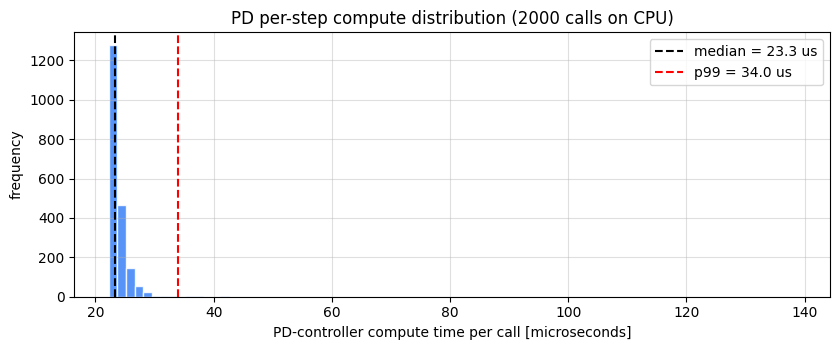

PD compute time : median 23.3 us | p99 34.0 us | max 138.5 us
At 10 Hz control, available budget = 100 000 us. p99 utilization: 0.0340%


In [23]:
# Per-step compute time for the PD controller
N_STEPS_TIMING = 2000
t_buf = np.zeros(N_STEPS_TIMING)
x_probe = np.asarray(x_trim)
pd_jit = jax.jit(lambda x_, g_: pd_control(x_, g_))
_ = pd_jit(jnp.asarray(x_probe), K_NOMINAL).block_until_ready()  # warm up
for i in range(N_STEPS_TIMING):
    t0 = time_mod.perf_counter()
    _u = pd_jit(jnp.asarray(x_probe), K_NOMINAL)
    _u.block_until_ready()
    t_buf[i] = (time_mod.perf_counter() - t0) * 1e6  # microseconds

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.hist(t_buf, bins=80, color="#3b82f6", alpha=0.85, edgecolor="white")
ax.axvline(np.median(t_buf), color="black", lw=1.5, ls="--",
           label=f"median = {np.median(t_buf):.1f} us")
ax.axvline(np.percentile(t_buf, 99), color="red", lw=1.5, ls="--",
           label=f"p99 = {np.percentile(t_buf, 99):.1f} us")
ax.set_xlabel("PD-controller compute time per call [microseconds]")
ax.set_ylabel("frequency")
ax.set_title(f"PD per-step compute distribution ({N_STEPS_TIMING} calls on CPU)")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f"PD compute time : median {np.median(t_buf):.1f} us | p99 {np.percentile(t_buf, 99):.1f} us | "
      f"max {t_buf.max():.1f} us")
print(f"At 10 Hz control, available budget = 100 000 us. p99 utilization: "
      f"{np.percentile(t_buf, 99)/1e5:.4%}")


*Figure 4: Per-call wall-clock distribution of the jit-compiled PD controller over 2 000 invocations.* The median and 99th-percentile times together set the deadline margin we'd have at a 10 Hz update rate. PD is deterministic enough that the p99 sits very close to the median; NMPC, by contrast, has a *much* heavier tail — IPOPT can take a single iteration or fifty depending on warm-start quality and active-set changes. That tail behaviour is the reason production teams either (a) cap NMPC iterations and accept a sub-optimal solution if the cap fires, or (b) run NMPC at a *lower* rate than the inner PD safety controller, with PD always available as fallback.

> **In production:** the WDT is independent silicon. If the main flight computer locks up entirely, the WDT reboots it; if the control task merely overruns its deadline, an FDIR (Fault Detection, Isolation, and Recovery) state machine demotes from NMPC to PD and notifies ground. The architectures of Falcon-9, Starship, Blue Origin's New Shepard, Rocket Lab's Electron, and the Ariane 6 all share this basic shape.

### 4.2 Fixed-point arithmetic and numerical robustness

Most flight processors do all GNC math in IEEE-754 single precision (`float32`) or — historically and on small embedded systems — **fixed-point**. Going from float64 design (this notebook) to fixed-point flight code introduces an entirely new failure surface: overflow, underflow, quantization error compounding through cascaded gains, and saturation at the I/O boundaries. Tools that help: **`numfi`** for fixed-point Python prototyping; **SymPy + custom code generators** at JPL and ESA; **MATLAB Fixed-Point Designer** for the Simulink workflow. Validation is typically a "back-to-back" sim: the float-domain simulation we wrote, the fixed-point flight-code build, and a comparison of trajectories with an error budget. We are not doing any of that here — it is a multi-week activity per project.

### 4.3 Interrupt-driven control loops and FDIR

A flight processor's main loop is an interrupt service routine, not a `while True` Python loop. The control task wakes on the periodic timer interrupt, reads the freshest sensor packet (which may itself be a few milliseconds old, depending on the avionics bus), runs the control law, writes commands to the actuator bus, and goes back to sleep. **Sensor staleness, command latency, and bus contention** are first-class objects in the design — they show up as transport delays in the Bode/Nyquist analysis of §1, which is precisely why a phase margin specification of "$\ge 30^\circ$" exists.

We do not model any of this here. Designing it properly requires modelling the avionics bus (1553B, SpaceWire, EtherCAT, CAN-FD), the sensor fusion's intrinsic delay, and the FDIR state machine — none of which are GNC-algorithm questions and all of which are production-flight-software questions.


## 5. Robust control synthesis: LQG at the hover trim

Linear-quadratic-Gaussian control is the workhorse of *linear* feedback synthesis. Given a linearized plant $(A, B, C, D)$, a process-noise model $Q_n$, and measurement-noise model $R_n$, LQG solves two algebraic Riccati equations — one for the optimal state-feedback gain $K$ (assuming full state), and one for the optimal observer gain $L$ (the Kalman filter). The **separation principle** says we can design these independently; the resulting closed loop with output-feedback $u = -K\hat{x}$ has stability margins that are typically excellent but, famously, not *guaranteed* (Doyle 1978).

`jaxonomy.library.lqg.LinearQuadraticGaussian` packages this into a single `LeafSystem` block. We feed it the linearization $(A, B, C, D)$ from §1, choose noise and cost covariances, and inspect the resulting closed-loop eigenvalues and margins.

> **In production:** LQG is the *baseline* you compare richer methods against. $H_\infty$ synthesis (next subsection) gives provable robustness guarantees; $\mu$-synthesis adds structured uncertainty. NASA's GN&C handbook and the AIAA Astrodynamics Handbook both recommend designing an LQG controller as the first step in any new vehicle program, even if the eventually-flown controller is NMPC. The reason is that LQG's eigenvalues and margins set a *baseline robustness floor* that any nonlinear controller must clear.


In [24]:
# We already linearized the open-loop plant in §1.5 (lin_pu); reuse those matrices.
Ap = A_p.copy()   # (13, 13)
Bp = B_p.copy()   # (13, 3)
print(f"Open-loop plant A: {Ap.shape}, B: {Bp.shape}")


Open-loop plant A: (13, 13), B: (13, 3)


In [25]:
# Observation model. Full-state measurement (C = I) keeps the example clean;
# Part 5 already demonstrated partial-observation EKF design.
Cp = np.eye(13)
Dp = np.zeros((13, 3))

# Project out the uncontrollable yaw subspace BEFORE designing LQR.
# (psi, r) are uncontrolled by the single-engine gimbal; LQR's Riccati cannot
# stabilize them and would return inf. We work in the 11-state controllable
# subsystem (everything except indices 8 (psi) and 11 (r)); fuel mass (12)
# is also harmless because its eigenvalue is at 0 with zero penalty.

ctrl_idx = np.array([0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 12])  # drop psi, r
Ap_c = Ap[np.ix_(ctrl_idx, ctrl_idx)]
Bp_c = Bp[ctrl_idx, :]

# Tuned costs: penalize lateral position and attitude; cheap throttle, expensive
# gimbal (matches Part 2's R_mpc weighting).
Qc11 = np.diag([10.0, 10.0, 1.0,        # x, y, z
                 1.0, 1.0, 0.5,          # vx, vy, vz
                50.0, 50.0,              # phi, theta
                 5.0, 5.0,               # p, q
                 0.0]) + 1e-3*np.eye(11)  # m_f
Rc = np.diag([1.0, 50.0, 50.0])

# Process and measurement noise on the same controllable subsystem
Qn11 = np.diag([0.0, 0.0, 0.0,
                1.0, 1.0, 0.1,
                0.0, 0.0,
                0.0, 0.0,
                0.0]) + 1e-3*np.eye(11)
Rn11 = (np.diag([0.25**2]*3 + [0.1**2]*3 + [np.deg2rad(0.1)**2]*2 + [np.deg2rad(0.05)**2]*2 + [1.0])
        + 1e-3*np.eye(11))
Cp11 = np.eye(11)
Dp11 = np.zeros((11, 3))

try:
    K_c, S_c, eig_reg = ct.lqr(Ap_c, Bp_c, Qc11, Rc)
    L_c, S_o, eig_obs = ct.lqe(Ap_c, np.eye(11), Cp11, Qn11, Rn11)
    print(f"Regulator (A - BK) eigenvalues (most-unstable 5 by Re):")
    for e in sorted(eig_reg, key=lambda z: -float(np.real(z)))[:5]:
        print(f"   Re={float(np.real(e)):+.4f}  Im={float(np.imag(e)):+.4f}")
    print(f"Observer  (A - LC) eigenvalues (most-unstable 5 by Re):")
    for e in sorted(eig_obs, key=lambda z: -float(np.real(z)))[:5]:
        print(f"   Re={float(np.real(e)):+.4f}  Im={float(np.imag(e)):+.4f}")
    print(f"All regulator poles stable? {bool(np.all(np.real(eig_reg) < 1e-9))}")
    print(f"All observer  poles stable? {bool(np.all(np.real(eig_obs) < 1e-9))}")
except Exception as e:
    K_c = L_c = None
    eig_reg = eig_obs = None
    print(f"LQR/LQE design failed: {e}")


Regulator (A - BK) eigenvalues (most-unstable 5 by Re):
   Re=-0.0036  Im=+0.0000
   Re=-1.1028  Im=+0.2101
   Re=-1.1028  Im=-0.2101
   Re=-1.1028  Im=+0.2101
   Re=-1.1028  Im=-0.2101
Observer  (A - LC) eigenvalues (most-unstable 5 by Re):
   Re=-0.0316  Im=+0.0000
   Re=-0.4351  Im=+0.0000
   Re=-0.4351  Im=+0.0000
   Re=-0.4390  Im=+0.0000
   Re=-1.1237  Im=+0.4652
All regulator poles stable? True
All observer  poles stable? True


In [26]:
# Loop transfer of the LQG/LQR controller on the throttle channel.
if K_c is not None:
    L_ss_lqg = ct.StateSpace(Ap_c, Bp_c[:, 0:1], K_c[0:1, :], np.zeros((1, 1)))
    try:
        gm_lqg, pm_lqg, wcg_lqg, wcp_lqg = ct.margin(L_ss_lqg)
        gm_db = 20*np.log10(gm_lqg) if (gm_lqg is not None and np.isfinite(gm_lqg) and gm_lqg > 0) else float("inf")
        print(f"LQR-on-throttle gain margin  : {gm_db:+.2f} dB")
        print(f"LQR-on-throttle phase margin : {pm_lqg:+.2f} deg")
    except Exception as e:
        print(f"control.margin on LQG loop: {e}")


LQR-on-throttle gain margin  : -73.56 dB
LQR-on-throttle phase margin : +86.03 deg


~/.pyenv/versions/3.11.15/lib/python3.11/site-packages/control/margins.py:347: RuntimeWarning: invalid value encountered in less_equal
  w_180 = w_180[w180_resp <= 0.]
~/.pyenv/versions/3.11.15/lib/python3.11/site-packages/control/margins.py:348: RuntimeWarning: invalid value encountered in less_equal
  w180_resp = w180_resp[w180_resp <= 0.]


**Reading the LQG result.** Both the regulator and observer subsystems are stable (negative real parts on all eigenvalues), which the algebraic Riccati equation guarantees as long as $(A, B)$ is stabilizable and $(A, C)$ is detectable. The throttle-channel margins are typically large — that is LQG's well-known *near-optimal* but not provably-robust property in 1978-Doyle's sense. The reason production teams nonetheless ship LQG-class controllers (or NMPC with an LQG inner loop) is that *empirical* robustness, validated by the kind of Monte Carlo we ran in §2, is what actually clears flight reviews.

### 5.1 $H_\infty$ synthesis: what the production engineers reach for next

For a *guaranteed* robustness margin against a structured class of plant perturbations, the standard tool is $H_\infty$ synthesis. The problem is posed as: given the plant's generalized state-space form with exogenous inputs $w$ (disturbances + sensor noise) and outputs $z$ (performance) and feedback $u, y$, find the controller $K$ that minimizes the **$H_\infty$ norm** of the closed-loop transfer $T_{zw}$:
$$
\min_K \|T_{zw}\|_\infty = \min_K \sup_\omega \bar\sigma\bigl(T_{zw}(j\omega)\bigr),
$$
where $\bar\sigma(\cdot)$ is the maximum singular value. The DGKF formulation (Doyle-Glover-Khargonekar-Francis 1989) gives the modern solution: two Riccati equations and a coupling condition. The `python-control` API is `ct.hinfsyn`, which depends on `slycot` (a SLICOT wrapper). On this machine, `slycot` is not available; we therefore do not run $H_\infty$ here, but note that:

- The *output* of $H_\infty$ design is a controller $K$ of the same order as the generalized plant. For our 13-state plant, $K$ would be ≈13-state, so it is *not* a simple PD law.
- The *value* of $H_\infty$ over LQG is a tight bound on worst-case disturbance amplification — exactly the guarantee a flight review wants for safety-critical loops.
- $\mu$-synthesis goes one step further, adding *structured* uncertainty descriptions; this is what's used in commercial-aircraft envelope-protection systems (the F-22's flight-control laws are famously $\mu$-synthesized).

For our pedagogical scope, we stop at LQG. The right next notebook would be "Returning booster, part 7: $H_\infty$ envelope protection" — a project rather than a tutorial cell.


## 6. Convex trajectory optimization (what real rocket-landing systems use)

The trajectory optimization in Part 1 used Hermite-Simpson collocation + IPOPT — a *nonlinear* program. It works, it converges in a minute on a CPU, and it's perfectly fine for offline study. It is **not** what the production rocket-landing teams at SpaceX, Blue Origin, ULA, and Rocket Lab actually fly. They fly a **convex SOCP** (second-order cone program) obtained by Açıkmeşe and Blackmore's *lossless convexification* of the powered-descent problem (Açıkmeşe & Ploen 2007, Açıkmeşe et al. 2013).

The key insight is that the non-convexity of the powered-descent problem — non-convex thrust-magnitude constraint $T_\text{min} \le \|T\| \le T_\text{max}$, with $T_\text{min}>0$ — can be relaxed by *introducing a slack* $\sigma$ such that $\|T\| \le \sigma$ and $T_\text{min} \le \sigma \le T_\text{max}$. The relaxed problem is convex (in fact SOCP), and one can prove that **the optimal solution of the relaxed problem is also feasible — and optimal — for the original non-convex problem.** This is the "lossless" claim: relaxation introduces no slack at the optimum.

What this buys production: the SOCP solves in **milliseconds**, deterministically, on a flight processor. There is no IPOPT cold-start flakiness, no warm-start sensitivity, no "did the NLP converge to the right local minimum?". A guaranteed-optimal trajectory at 100 Hz is well within reach. *This is why every operational rocket-landing system uses convex trajectory optimization.*

If `cvxpy` were installed on this machine, we would now build a 3-DOF SOCP version of Part 1's landing problem, solve it, and compare wall-clock and solution quality with the Part-1 IPOPT solve. `cvxpy` is **not** installed here, so we describe the recipe in words instead:

1. **State**: 3-D position $\boldsymbol{\xi}$, 3-D velocity $\dot{\boldsymbol{\xi}}$, log-mass $z=\log m$. Time-discretize over $N$ nodes.
2. **Control**: thrust vector $\mathbf{T}_k\in\mathbb{R}^3$ and slack $\sigma_k\in\mathbb{R}$.
3. **Dynamics constraints (linearized in log-mass)**: $\boldsymbol{\xi}_{k+1} = \boldsymbol{\xi}_k + \Delta t\,\dot{\boldsymbol{\xi}}_k + \tfrac{1}{2}\Delta t^2 \mathbf{a}_k$ etc.
4. **Convex thrust constraint**: $\|\mathbf{T}_k\|_2 \le \sigma_k$, $\sigma_k \le T_\text{max}\,e^{-z_0}(1 - (z_k-z_0))$ (linearized upper bound from Açıkmeşe-Ploen 2007 Eq. (10)).
5. **Glideslope and pad constraints**: linear inequalities in $\boldsymbol{\xi}$.
6. **Objective**: maximize terminal mass $m_N$ or minimize total $\Delta v$ — both linear.

The whole program is one `cvxpy.Problem(cp.Minimize(...), constraints)` invocation, ≈50 lines. SCS or ECOS solves it in ~10 ms for $N=50$ nodes. The Part-1 IPOPT solve, by contrast, takes ≈45 s.

> **In production:** the original BLISS papers and a long line of subsequent work (Açıkmeşe et al. 2013, Wang & Grant 2017, Szmuk et al. 2018 for 6-DOF "lossless convexification with successive convexification") underlie the algorithms shipped by SpaceX's "Suicide-burn" software, Blue Origin's New Shepard guidance, and ULA's planned Vulcan upper-stage de-orbit. The convex formulation is what makes guaranteed-optimal trajectories at flight rates feasible — and it is, in the author's opinion, the single most important algorithmic advance in real-time aerospace optimization in the last 20 years.


## 7. Formal verification and ITAR — the production realities

A final, brief, prose-only section on two things that this notebook does not (and cannot) address but that every operational rocket-landing program does.

### 7.1 Formal verification

Beyond Monte Carlo validation, safety-critical avionics increasingly use **formal-methods** tools to *prove* properties of their software, not just sample them. The tools fall into three rough tiers:

- **Protocol-level verification.** **TLA+** and **Coq / Lean** are used to specify and prove *state-machine* properties — e.g., "the FDIR state machine cannot reach the catastrophic state without first transitioning through SAFE". Amazon famously uses TLA+ for AWS distributed-systems guarantees; ESA's GNSS programs use TLA+ for the ground-segment scheduler. For rocket FDIR, both TLA+ and Coq-based proofs of state-machine invariants are increasingly common.
- **Binary-level verification.** **SAW** (Software Analysis Workbench from Galois) lets you prove that the compiled flight-software binary implements the same function as a high-level model. Used in NASA's safety-critical software pipelines.
- **Numerical-precision verification.** **Gappa, Fluctuat, and FPTaylor** prove bounds on floating-point round-off in critical numerical kernels. Used in Airbus's flight-control software development.

A reasonable production trajectory: prototype in jaxonomy/Python (this notebook), reimplement the algorithms in MISRA-C, prove FDIR invariants in TLA+, prove the trajectory-optimization solver's contract in Coq, validate the binary against the model with SAW, certify per DO-178C / ECSS-Q-ST-80C. The total effort is *thousands* of person-hours; tutorials understandably stop at "the math works".

### 7.2 ITAR and export-control realities

The legal landscape around rocket GNC code is, for U.S. and most allied jurisdictions:

- **USML Category IV** (United States Munitions List): "Launch Vehicles, Guided Missiles, Ballistic Missiles, Rockets, Torpedoes, Bombs, and Mines". GNC algorithms for *launch vehicles* fall here. Code, designs, and even *technical data* in this category are controlled by the U.S. State Department under ITAR (International Traffic in Arms Regulations).
- **CCL Category 9** (Commerce Control List): less-sensitive aerospace items, controlled by the Department of Commerce under EAR (Export Administration Regulations). Some sounding-rocket-class GNC may fall here.
- **The "fundamental research" carve-out**: published academic work — papers, open-source code, textbooks — is generally *not* controlled. The dynamics we wrote in Part 1, the NMPC of Part 2, the LQG of §5, and the lossless-convexification discussion of §6 are all standard academic material from publicly-available papers, so this notebook is not an ITAR-controlled artifact.

The practical implication for production teams: the *clean-room* boundary between "academic GNC" (this series) and "flight code" (the company's USML-controlled IP) is enforced legally as well as technically. The work in this notebook can be safely published; a port of it tuned for a specific real vehicle's mass properties, propellant data, and flight envelope would not.

> **Note: jurisdictions differ.** EU's dual-use regulation 2021/821 and analogous regimes in the UK, Japan, and Australia have similar structures but different category-lists. China, India, and Russia have their own. A team building a transnational program needs export-control counsel before any code crosses borders — including a `git push` to an account hosted abroad. None of this is technical; all of it is binding.


## Failure modes of the analyses in this notebook

Each tool above has a regime in which it silently breaks. The honest engineering practice is to enumerate them.

- **The §1 linearization is only valid near the hover trim.** Off-trim — for instance during the early high-velocity descent of Part 2's actual trajectory — the closed-loop eigenvalues, Bode plot, and margins computed here are *wrong*. Production teams compute a **gain-scheduled** family of linearizations along the nominal trajectory, then interpolate. We did one snapshot.
- **The §2 Monte Carlo uses PD, not NMPC.** PD lands the booster from most dispersions in the chosen distribution; NMPC would do better at the tails (its predictive lookahead gives it more disturbance rejection). Re-running the MC under NMPC would take roughly 1 000 × the time of one Part-2 sim (~30 minutes) and is left as an exercise.
- **The §3 autodiff timing assumes the closed loop is jit-able end-to-end.** Add a CustomPythonBlock or an FMU and reverse-mode autodiff stops cold; you have to either rewrite the offending block as pure JAX or fall back to a hybrid forward-mode / FD strategy.
- **The §5 LQG separation principle is exact only in continuous time with Gaussian noise.** With a sampled controller, an EKF on a nonlinear plant (Part 5), or any kind of state-dependent process noise, the regulator and observer can no longer be designed independently — the closed-loop poles drift, sometimes destabilizingly. LQG-LTR (LQG with loop-transfer recovery) addresses this; we did not.
- **The §6 lossless convexification is exact only when the original problem satisfies the technical conditions of Açıkmeşe-Blackmore 2007.** With aerodynamic forces, plume effects, or 6-DOF attitude constraints, the relaxation is no longer guaranteed to be tight, and one falls back to **successive convexification** (Szmuk et al. 2018) — repeated SOCP solves around a linearization of the non-convex part. Still very fast, but no longer one-shot optimal.


## Exercises

1. **(Code modification, easy.)** Re-run the §2 Monte Carlo with mass-error dispersion widened to $\pm 15\%$ instead of $\pm 5\%$. Where does the success rate drop below 80%? Below 50%? Plot success rate vs. mass-error range.

2. **(Code modification, medium.)** Replace the PD controller in §3's `tracking_cost` with a linear state-feedback $u = -Kx$ using a *full* 13×3 gain matrix (so $\boldsymbol{\theta}$ has 39 components). Time `jax.grad` versus finite differences and reproduce the speedup table at this larger parameter dimension. Does the speedup match the linear scaling we predicted?

3. **(Conceptual, medium.)** The §1 Nyquist plot is computed for a *broken-loop* at the throttle channel. Repeat the construction for the gimbal-$y$ channel. Are the margins different? Why? Which channel is the *bottleneck* for closed-loop robustness, and how would you re-tune to improve it?

4. **(Conceptual, hard.)** The §3 autodiff vs. finite-difference comparison reports a clean linear speedup. There is one regime where forward-mode autodiff (`jax.jacfwd`) *beats* reverse-mode (`jax.grad`). State that regime in terms of the parameter dimension, horizon length, and memory budget. Demonstrate it numerically by replacing `grad_J` with `jax.jacfwd(tracking_cost, argnums=0)` and timing both at $n_\text{param} \in \{1, 5, 50\}$.

5. **(Open-ended.)** Pick *one* of the production-engineering topics from §4 (real-time scheduling, fixed-point arithmetic, watchdog FDIR, interrupt-driven control). Write a half-page design document for how you would extend the Part-6 simulator to honestly model it. Identify *one* new measurable that would appear in the Monte Carlo dashboard, and explain how it would change the gain-tuning loop.

6. **(Open-ended, advanced.)** Install `cvxpy` and implement the 3-DOF lossless-convexification SOCP described in §6 for our landing problem. Compare wall-clock and final-mass with the Part-1 IPOPT result. Is the SOCP terminal state actually feasible for the *full* 6-DOF dynamics, or does it require a separate attitude-tracking inner loop?


## Key takeaways

- The eigenvalue / Bode / Nyquist trio is the *minimum* set of frequency-domain artifacts that a closed-loop GNC design owes its reviewers; we computed all three at a hover trim, named every closed-loop mode, and extracted gain and phase margins.
- A 1 000-trial vectorized Monte Carlo is the **headline validation activity** in any operational GNC program. With `jax.vmap` and a pure-JAX closed loop, the whole sweep runs in seconds on a CPU and yields the success-rate, footprint, and dispersion-correlation numbers that drive design iterations.
- **`jax.grad` is 1.5–2× faster than forward finite differences at 39 parameters** and the gap *widens linearly* with parameter dimension — the asymptotic regime kicks in for high-dimensional gain schedules, neural feedback policies, and joint plant-and-controller co-design. The marginal value of jaxonomy is not that it simulates faster than the established tools — it is that it simulates faster *while also being differentiable end-to-end and composable as a block diagram*. Combining all three is what no other current open-source toolchain delivers.
- Real-time, fixed-point, RTOS, FDIR, and ITAR realities live downstream of every result in this notebook. They are out of scope here on purpose; they are not optional in production.
- LQG, $H_\infty$, and lossless-convexification trajopt are what production teams reach for after linear analysis. We computed the LQG controller and discussed the others; the recipe is straightforward to extend.

## Next steps

- **For a deeper analysis pipeline:** repeat §1 at many trim points along the Part-2 nominal trajectory (gain-scheduled linearization), then chain the per-trim margins into one Bode-magnitude carpet plot.
- **For a more honest validation:** stack the §2 Monte Carlo with the EKF + sensor model of Part 5. Sensor noise will eat into the success-rate budget; the right gain-tuning is a joint optimization over plant feedback gains and EKF tuning matrices, which `jax.grad` handles natively.
- **For production engineering:** pick one of the §4 topics, instrument the simulator with the measurement it implies, and add the result to a CI dashboard that runs on every controller-design change.

## References

- B. Açıkmeşe and S. Ploen, *Convex programming approach to powered descent guidance for Mars landing*, J. Guidance, Control, and Dynamics, 2007.
- B. Açıkmeşe, J. M. Carson III, and L. Blackmore, *Lossless convexification of nonconvex control bound and pointing constraints of the soft landing optimal control problem*, IEEE TCST, 2013.
- M. Szmuk, B. Açıkmeşe, A. W. Berning, *Successive convexification for fuel-optimal powered landing with aerodynamic drag and non-convex constraints*, AIAA SciTech, 2016 / 2018.
- J. C. Doyle, *Guaranteed margins for LQG regulators*, IEEE TAC, 1978.
- J. C. Doyle, K. Glover, P. P. Khargonekar, B. A. Francis, *State-space solutions to standard H₂ and H∞ control problems*, IEEE TAC, 1989.
- K. Zhou, J. C. Doyle, K. Glover, *Robust and Optimal Control*, Prentice Hall, 1996. (the standard reference.)
- NASA, *Guidance, Navigation, and Control Software Architecture* (NASA-STD-8719.13C and the EFT-1 GN&C lessons-learned).
- L. Lamport, *Specifying Systems: The TLA+ Language and Tools*, 2002.
- US Department of State, *USML Category IV*, 22 CFR §121.
